Cell 0 — Colab-safe setup: install deps, mount Drive, read S2, mask NoData

In [1]:
# Safe install cell
import os, sys

# flag file = marker that packages are installed
flag_file = "/content/.pkgs_installed"

if not os.path.exists(flag_file):
    # install correct versions once
    !pip install -q numpy==1.26.4 scikit-image==0.22.0 albumentations==1.3.1 opencv-python-headless==4.10.0.84 scipy==1.12.0 matplotlib==3.8.0
    open(flag_file, "w").close()   # create marker file
    print("[INFO] Packages installed. Please restart runtime, then Run all again.")
    sys.exit(0)   # stop only this first run
else:
    print("[INFO] Packages already installed. Continue...")

[INFO] Packages already installed. Continue...


In [2]:
# Install dependencies once
import os, sys, subprocess, time
import numpy as np
from pathlib import Path

def pipq(args: str):
    """Run pip inside Python."""
    subprocess.check_call([sys.executable, "-m", "pip"] + args.split())

SENTINEL = Path("/content/.once_rs_deps")
if not SENTINEL.exists():
    pipq("install -qU pip wheel setuptools")
    pipq("install -q numpy==1.26.4 rasterio==1.3.10 pyproj>=3.6 gdal")
    SENTINEL.touch()

import rasterio
from google.colab import drive
from pyproj.datadir import get_data_dir

# Configure PROJ data directory
PROJ_DIR = get_data_dir()
os.environ["PROJ_LIB"] = PROJ_DIR
os.environ["PROJ_DATA"] = PROJ_DIR
os.environ.setdefault("PROJ_NETWORK", "ON")

# Use GeoTIFF keys for CRS to avoid warnings
READ_CRS_FROM = "GEOKEYS"

# Define paths
DRIVE_MOUNT_POINT = "/content/drive"
TIF_PATH = f"{DRIVE_MOUNT_POINT}/MyDrive/GEE_Exports/veys_sheyban_s2_2025_11b_BAL.tif"

# Classes
SOIL, VEG, WATER = 0, 1, 2
CLASS_NAMES = ["soil", "vegetation", "water"]
PALETTE_RGB = {SOIL: (139, 69, 19), VEG: (34, 139, 34), WATER: (30, 144, 255)}

# Project folders
RUN_ROOT   = Path(f"{DRIVE_MOUNT_POINT}/MyDrive/AgriSeg/runs").resolve()
PATCH_ROOT = Path(f"{DRIVE_MOUNT_POINT}/MyDrive/AgriSeg/patches").resolve()
FIG_DIR    = Path(f"{DRIVE_MOUNT_POINT}/MyDrive/AgriSeg/figures").resolve()
EXP_DIR    = Path(f"{DRIVE_MOUNT_POINT}/MyDrive/AgriSeg/exports").resolve()

# Mount Drive
def safe_unmount(mount_point: str):
    try:
        get_ipython().system(f"fusermount -u {mount_point} || true")
    except Exception:
        pass

safe_unmount(DRIVE_MOUNT_POINT)
drive.mount(DRIVE_MOUNT_POINT, force_remount=True)

for p in [RUN_ROOT, PATCH_ROOT, FIG_DIR, EXP_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Read GeoTIFF
if not os.path.exists(TIF_PATH):
    raise FileNotFoundError(f"[ERROR] GeoTIFF not found:\n  {TIF_PATH}")

t0 = time.time()
with rasterio.Env(GDAL_CACHEMAX=512, GTIFF_SRS_SOURCE=READ_CRS_FROM):
    with rasterio.open(TIF_PATH, sharing=False) as src:
        meta   = src.meta.copy()
        bounds = src.bounds
        nodata = src.nodata
        original_band_count = int(meta.get("count", 0))
        band_names = list(src.descriptions)

        if band_names:
            BAND_MAP = {name: i + 1 for i, name in enumerate(band_names)}
            SELECTED_BANDS = band_names
        else:
            SELECTED_BANDS = [f"band_{i+1}" for i in range(original_band_count)]
            BAND_MAP = {n: i + 1 for i, n in enumerate(SELECTED_BANDS)}

        arr = src.read(indexes=list(range(1, len(SELECTED_BANDS) + 1)))
        img_hwc = np.transpose(arr, (1, 2, 0)).astype(np.float32, copy=False)

        crs_value = src.crs if src.crs is not None else meta.get("crs", None)
        meta["crs"] = crs_value

t1 = time.time()

# Apply NoData mask
H, W, C = img_hwc.shape
if nodata is not None and np.isfinite(nodata):
    nodata_mask = np.all(np.isclose(img_hwc, nodata, atol=1e-6), axis=-1)
else:
    nodata_mask = np.all(np.isclose(img_hwc, 0.0, atol=1e-6), axis=-1)

if np.any(nodata_mask):
    img_hwc[nodata_mask] = np.nan

# QA report
tr = meta.get("transform", None)
px_size_x = tr[0] if tr is not None else None
px_size_y = -tr[4] if tr is not None else None
nodata_pct = 100.0 * float(nodata_mask.sum()) / (H * W)

print("[INFO] Sentinel-2 loaded.")
print(f"[INFO] Path:              {TIF_PATH}")
print(f"[INFO] Shape (H,W,C):     {img_hwc.shape}")
print(f"[INFO] Bands detected:    {band_names}")
print(f"[INFO] CRS:               {meta['crs']}")
print(f"[INFO] Pixel size (m):    {px_size_x} x {px_size_y}")
print(f"[INFO] Bounds:            {bounds}")
print(f"[INFO] NoData value:      {nodata}   | masked pixels: {nodata_pct:.2f}%")
print(f"[INFO] IO time:           {t1 - t0:.2f}s")

# Water band statistics
water_bands = [b for b in ["NDWI", "MNDWI", "AWEI_sh"] if b in band_names]
for wb in water_bands:
    idx = BAND_MAP[wb] - 1
    band_data = img_hwc[..., idx]
    valid_mask = ~np.isnan(band_data)
    if valid_mask.sum() > 0:
        mean_val = float(np.nanmean(band_data))
        water_frac = 100.0 * np.sum(band_data > 0.3) / valid_mask.sum()
        print(f"[WATER-QA] {wb}: mean={mean_val:.3f} | >0.3 fraction={water_frac:.2f}%")
    else:
        print(f"[WATER-QA] {wb}: no valid pixels")

# Expose variables
_ = (
    img_hwc, meta, bounds, nodata, nodata_mask, original_band_count,
    SELECTED_BANDS, BAND_MAP, RUN_ROOT, PATCH_ROOT, FIG_DIR, EXP_DIR,
    True, SOIL, VEG, WATER, CLASS_NAMES, PALETTE_RGB
)


fusermount: failed to unmount /content/drive: No such file or directory
Mounted at /content/drive
[INFO] Sentinel-2 loaded.
[INFO] Path:              /content/drive/MyDrive/GEE_Exports/veys_sheyban_s2_2025_11b_BAL.tif
[INFO] Shape (H,W,C):     (1879, 1875, 11)
[INFO] Bands detected:    ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'EVI', 'AWEI_sh']
[INFO] CRS:               EPSG:32639
[INFO] Pixel size (m):    10.0 x 10.0
[INFO] Bounds:            BoundingBox(left=280510.0, bottom=3471210.0, right=299260.0, top=3490000.0)
[INFO] NoData value:      None   | masked pixels: 0.00%
[INFO] IO time:           6.22s
[WATER-QA] NDWI: mean=-0.416 | >0.3 fraction=2.76%
[WATER-QA] MNDWI: mean=-0.338 | >0.3 fraction=2.54%
[WATER-QA] AWEI_sh: mean=-1.056 | >0.3 fraction=0.22%


Cell 1 — Reuse loaded image, robust per-band stats (p2–p98), safe QA

In [3]:
import time, numpy as np, rasterio

t0 = time.time()

# Load selected bands from GeoTIFF
def _read_selected_bands(tif_path, band_map, selected):
    with rasterio.open(tif_path, sharing=False) as src:
        idxs = [band_map[b] for b in selected]  # band indices (1-based)
        arr = src.read(indexes=idxs)            # (C,H,W)
        meta = src.meta.copy()
        bounds = src.bounds
        nodata = src.nodata
    return np.transpose(arr, (1, 2, 0)).astype(np.float32), meta, bounds, nodata

# Read image if not already in memory
if 'img_hwc' not in globals() or 'meta' not in globals():
    print("[WARN] Previous cell not found in memory → reading image now.")
    img_hwc, meta, bounds, nodata = _read_selected_bands(TIF_PATH, BAND_MAP, SELECTED_BANDS)
    nodata_mask = None

# Image shape and pixel size
H, W, C = img_hwc.shape
tr = meta.get('transform', None)
px_size_x = tr[0] if tr is not None else None
px_size_y = -tr[4] if tr is not None else None

print(f"[INFO] Loaded: {TIF_PATH}")
print(f"[INFO] Shape: {H}×{W}×{C} | CRS: {meta.get('crs')} | Pixel: {px_size_x}×{px_size_y} m | NoData: {meta.get('nodata')}")

# Compute robust min/max (p2–p98) for reflectance bands
def compute_band_stats(arr, orig_band_names, p_lo=2, p_hi=98):
    stats = []
    for bname in orig_band_names:
        idx = BAND_MAP[bname] - 1
        vals = arr[..., idx]
        finite = np.isfinite(vals)
        if not np.any(finite):
            stats.append((0.0, 1.0))
            continue
        lo, hi = np.nanpercentile(vals[finite], [p_lo, p_hi])
        if hi - lo < 1e-6:
            lo = float(np.nanmin(vals[finite]))
            hi = float(np.nanmax(vals[finite]) + 1e-6)
        stats.append((float(lo), float(hi)))
    return stats

# Select original reflectance bands (10m + 20m resampled)
orig_reflectance = [b for b in ['B2','B3','B4','B8','B11','B12'] if b in SELECTED_BANDS]
BAND_STATS = compute_band_stats(img_hwc, orig_reflectance, 2, 98)

print("[INFO] BAND_STATS (p2–p98) for reflectance bands:")
for bname, (lo, hi) in zip(orig_reflectance, BAND_STATS):
    print(f"  {bname}: lo={lo:.3f}, hi={hi:.3f}")

# Compute statistics for water indices
water_indices = [b for b in ['NDWI','MNDWI','AWEI_sh'] if b in SELECTED_BANDS]
if water_indices:
    print("\n[WATER-QA] Water index statistics:")
    for wb in water_indices:
        idx = BAND_MAP[wb] - 1
        vals = img_hwc[..., idx]
        finite = np.isfinite(vals)
        if finite.sum() == 0:
            print(f"  {wb}: no valid data")
            continue
        mean_val = float(np.nanmean(vals))
        water_frac = 100.0 * np.sum(vals > 0.3) / finite.sum()
        print(f"  {wb}: mean={mean_val:.3f} | >0.3 fraction={water_frac:.2f}%")

print(f"\n[INFO] Done in {time.time()-t0:.2f}s")

# Save band statistics for later use
ORIG_BANDS = len(orig_reflectance)
_ = (ORIG_BANDS, BAND_STATS, orig_reflectance)


[INFO] Loaded: /content/drive/MyDrive/GEE_Exports/veys_sheyban_s2_2025_11b_BAL.tif
[INFO] Shape: 1879×1875×11 | CRS: EPSG:32639 | Pixel: 10.0×10.0 m | NoData: None
[INFO] BAND_STATS (p2–p98) for reflectance bands:
  B2: lo=0.022, hi=0.203
  B3: lo=0.047, hi=0.251
  B4: lo=0.024, hi=0.303
  B8: lo=0.023, hi=0.452
  B11: lo=0.026, hi=0.404
  B12: lo=0.024, hi=0.382

[WATER-QA] Water index statistics:
  NDWI: mean=-0.416 | >0.3 fraction=2.76%
  MNDWI: mean=-0.338 | >0.3 fraction=2.54%
  AWEI_sh: mean=-1.056 | >0.3 fraction=0.22%

[INFO] Done in 0.32s


Cell 2 — Compute NDVI, NDWI, (optional) EVI with NaN-safe ops

In [4]:
import time, numpy as np, rasterio

EPS = 1e-6
ADD_EVI = True  # set False if you do not want EVI

t0 = time.time()

# Copy image and build a finite-pixel mask
img = img_hwc.astype(np.float32, copy=True)
finite_mask = np.isfinite(img).all(axis=-1)

# Build band index map (1-based names → 0-based array indices)
idx = {b: SELECTED_BANDS.index(b) for b in SELECTED_BANDS}

# Aliases for common bands (set to None if missing)
blue  = img[..., idx["B2"]]
green = img[..., idx["B3"]]
red   = img[..., idx["B4"]]
nir   = img[..., idx["B8"]]
swir1 = img[..., idx["B11"]] if "B11" in idx else None
swir2 = img[..., idx["B12"]] if "B12" in idx else None

# Compute indices
with np.errstate(divide='ignore', invalid='ignore'):
    ndvi  = (nir - red)   / (nir + red + EPS)
    ndwi  = (green - nir) / (green + nir + EPS)
    mndwi = (green - swir1) / (green + swir1 + EPS) if swir1 is not None else None

    evi = None
    if ADD_EVI:
        evi = 2.5 * (nir - red) / (nir + 6.0*red - 7.5*blue + 1.0 + EPS)

    awei_sh = None
    if swir1 is not None and swir2 is not None:
        awei_sh = (4 * (green - swir1) - (0.25 * nir + 2.75 * swir2))

# Clip to a safe range where appropriate
def safe_clip(arr, lo=-1.0, hi=1.0):
    out = np.full_like(arr, np.nan, dtype=np.float32)
    out[finite_mask] = np.clip(arr[finite_mask], lo, hi)
    return out[..., None]

ndvi  = safe_clip(ndvi)
ndwi  = safe_clip(ndwi)
mndwi = safe_clip(mndwi) if mndwi is not None else None
if evi is not None:
    evi = safe_clip(evi)
if awei_sh is not None:
    # keep raw range for water detection
    awei_sh = awei_sh[..., None].astype(np.float32)

# Stack channels and names
channels = [img, ndvi, ndwi]
names    = SELECTED_BANDS + ["NDVI", "NDWI"]

if mndwi is not None:
    channels.append(mndwi)
    names.append("MNDWI")
if ADD_EVI and evi is not None:
    channels.append(evi)
    names.append("EVI")
if awei_sh is not None:
    channels.append(awei_sh)
    names.append("AWEI_sh")

img_with_indices = np.concatenate(channels, axis=-1).astype(np.float32)
NAME2IDX = {n: i for i, n in enumerate(names)}

print("[INFO] Channels prepared:", names)
print("[INFO] Final tensor shape:", img_with_indices.shape)


[INFO] Channels prepared: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'EVI', 'AWEI_sh', 'NDVI', 'NDWI', 'MNDWI', 'EVI', 'AWEI_sh']
[INFO] Final tensor shape: (1879, 1875, 16)


Cell 3 — RGB + NDVI preview and auto-labeling (soil, vegetation, water)

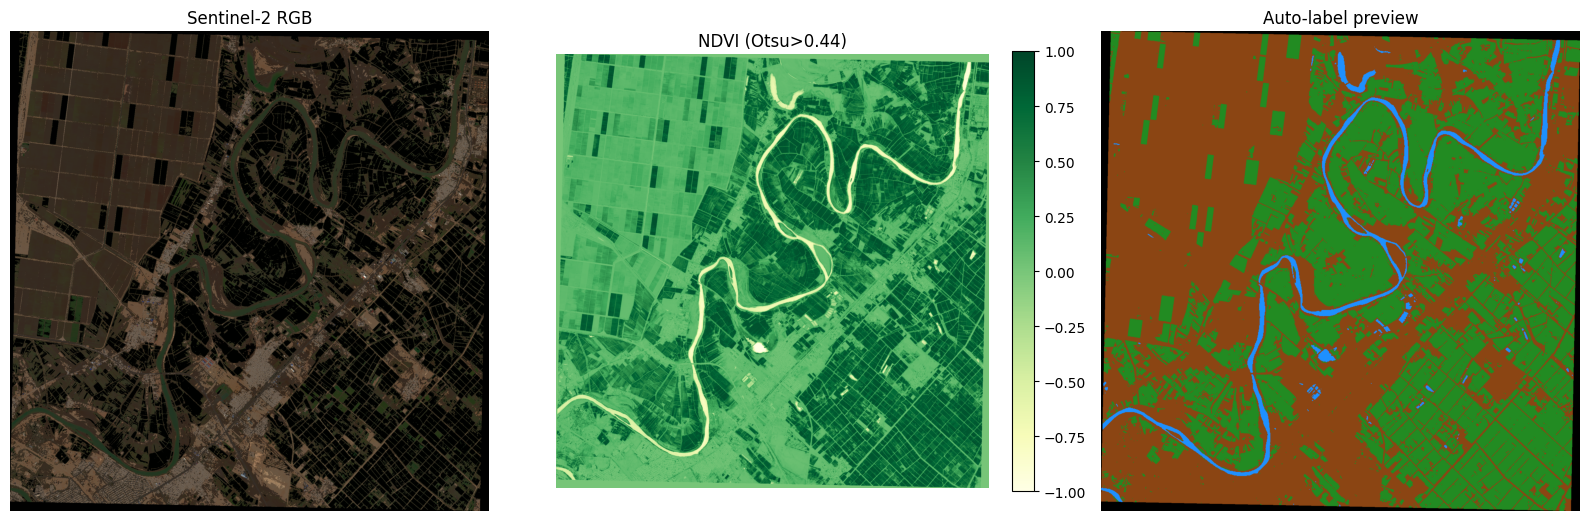

[INFO] NDVI Otsu threshold: 0.436
[INFO] MNDWI threshold: 0.098
[INFO] Class pixel counts: soil=1887536, veg=1406348, water=94283


In [5]:
import sys, subprocess

def pipi(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

try:
    import numpy as _np
    import skimage
except Exception:
    import numpy as _np
    np_major = int(_np.__version__.split(".")[0])
    if np_major >= 2:
        pipi(["scikit-image>=0.24.0"])  # works with NumPy 2
    else:
        pipi(["scikit-image==0.22.0"])  # works with NumPy 1
    import skimage

# Imports
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure
from skimage.filters import threshold_otsu
from skimage.morphology import binary_opening, binary_closing, disk

# Make sure figure folder exists
from pathlib import Path
try:
    FIG_DIR
except NameError:
    FIG_DIR = Path("./figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Check that needed variables exist
required = ["img_with_indices", "NAME2IDX", "PALETTE_RGB", "SOIL", "VEG", "WATER", "H", "W"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}")

# Extract maps
ndvi_map  = img_with_indices[..., NAME2IDX["NDVI"]]
ndwi_map  = img_with_indices[..., NAME2IDX["NDWI"]]
mndwi_map = img_with_indices[..., NAME2IDX["MNDWI"]] if "MNDWI" in NAME2IDX else None
awei_map  = img_with_indices[..., NAME2IDX["AWEI_sh"]] if "AWEI_sh" in NAME2IDX else None

# Build RGB preview with CLAHE
rgb = img_with_indices[..., [NAME2IDX["B4"], NAME2IDX["B3"], NAME2IDX["B2"]]].copy()
rgb = np.clip(rgb, 0, 10000) / 10000.0
rgb_disp = exposure.equalize_adapthist(rgb, clip_limit=0.02)

# Vegetation mask from NDVI
finite_ndvi = np.isfinite(ndvi_map)
ndvi_clean = np.zeros_like(ndvi_map, dtype=np.float32)
ndvi_clean[finite_ndvi] = ndvi_map[finite_ndvi]
t_ndvi = threshold_otsu(ndvi_clean[finite_ndvi])
veg_mask = ndvi_clean > t_ndvi
veg_mask = binary_opening(veg_mask, footprint=disk(1))
veg_mask = binary_closing(veg_mask, footprint=disk(1))

# Water mask from MNDWI (preferred) or NDWI
finite_ndwi = np.isfinite(ndwi_map)
ndwi_clean = np.zeros_like(ndwi_map, dtype=np.float32)
ndwi_clean[finite_ndwi] = ndwi_map[finite_ndwi]

if mndwi_map is not None:
    finite_mndwi = np.isfinite(mndwi_map)
    mndwi_clean = np.zeros_like(mndwi_map, dtype=np.float32)
    mndwi_clean[finite_mndwi] = mndwi_map[finite_mndwi]
    t_mndwi = threshold_otsu(mndwi_clean[finite_mndwi])
    water_mask_base = mndwi_clean > max(0.1, t_mndwi)
else:
    t_ndwi = threshold_otsu(ndwi_clean[finite_ndwi])
    water_mask_base = ndwi_clean > max(0.1, t_ndwi)

# Add water in shadow using AWEI if available
if awei_map is not None:
    finite_awei = np.isfinite(awei_map)
    awei_clean = np.zeros_like(awei_map, dtype=np.float32)
    awei_clean[finite_awei] = awei_map[finite_awei]
    shadow_water = awei_clean > 0
    water_mask_base = water_mask_base | shadow_water

# Final water mask (remove vegetation)
water_mask = water_mask_base & (~veg_mask)
water_mask = binary_opening(water_mask, footprint=disk(1))
water_mask = binary_closing(water_mask, footprint=disk(1))

# Soil mask
soil_mask = finite_ndvi & (~veg_mask) & (~water_mask)

# Build label map
label_map = np.full(ndvi_map.shape, fill_value=-1, dtype=np.int16)
label_map[soil_mask]  = SOIL
label_map[veg_mask]   = VEG
label_map[water_mask] = WATER

# Show preview figure
plt.figure(figsize=(16,6))
plt.subplot(1,3,1); plt.imshow(rgb_disp); plt.title("Sentinel-2 RGB"); plt.axis("off")
plt.subplot(1,3,2); im=plt.imshow(ndvi_clean, cmap="YlGn", vmin=-1, vmax=1)
plt.title(f"NDVI (Otsu>{t_ndvi:.2f})"); plt.axis("off"); plt.colorbar(im, fraction=0.046)
plt.subplot(1,3,3)
preview_rgb = np.zeros((H, W, 3), dtype=np.uint8)
for cls_id, color in PALETTE_RGB.items():
    preview_rgb[label_map == cls_id] = color
plt.imshow(preview_rgb); plt.title("Auto-label preview"); plt.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_rgb_ndvi_labels.png", dpi=200)
plt.show()

print(f"[INFO] NDVI Otsu threshold: {t_ndvi:.3f}")
if mndwi_map is not None:
    print(f"[INFO] MNDWI threshold: {t_mndwi:.3f}")
print(f"[INFO] Class pixel counts: soil={np.sum(label_map==SOIL)}, veg={np.sum(label_map==VEG)}, water={np.sum(label_map==WATER)}")

_ = (label_map,)


Cell 4 — Auto 3-class labels (Pro, Tile-wise Otsu + Seeded KMeans + Fusion)

/tmp/ipython-input-1726260926.py:30: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  m = opening(m, square(3))
/tmp/ipython-input-1726260926.py:31: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  m = closing(m, square(3))
/tmp/ipython-input-1726260926.py:30: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  m = opening(m, square(3))
/tmp/ipython-input-1726260926.py:31: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  m = closing(m, square(3))
/tmp/ipython-input-1726260926.py:30: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morp

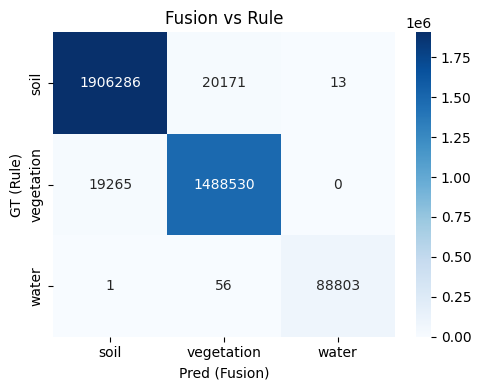

[INFO] Fused labeling complete.
[INFO] Baseline comparison (Fusion vs Rule-only):
         soil | Precision=0.990 | Recall=0.990 | F1=0.990 | IoU=0.980
   vegetation | Precision=0.987 | Recall=0.987 | F1=0.987 | IoU=0.974
        water | Precision=1.000 | Recall=0.999 | F1=1.000 | IoU=0.999


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.morphology import opening, closing, square, remove_small_objects, remove_small_holes
from scipy.ndimage import binary_fill_holes
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, jaccard_score
from skimage.filters import threshold_otsu

assert 'img_with_indices' in globals(), "[ERROR] Run previous cells first."

H, W, _ = img_with_indices.shape
ndvi_full = np.nan_to_num(img_with_indices[..., NAME2IDX["NDVI"]], nan=0.0).astype(np.float32)
ndwi_full = np.nan_to_num(img_with_indices[..., NAME2IDX["NDWI"]], nan=0.0).astype(np.float32)
mndwi_full = np.nan_to_num(img_with_indices[..., NAME2IDX.get("MNDWI", 0)], nan=0.0).astype(np.float32) if "MNDWI" in NAME2IDX else None
awei_full  = np.nan_to_num(img_with_indices[..., NAME2IDX.get("AWEI_sh", 0)], nan=0.0).astype(np.float32) if "AWEI_sh" in NAME2IDX else None
has_evi   = "EVI" in NAME2IDX
evi_full  = np.nan_to_num(img_with_indices[..., NAME2IDX.get("EVI", 0)], nan=0.0).astype(np.float32) if has_evi else None

# Parameters
BLOCK = 1024
STEP  = 512
W_RULE = 2.5  # weight for rule-based
W_KM   = 1.0
MIN_OBJ = 50

# Clean binary mask
def clean_mask(m, min_size=MIN_OBJ):
    m = opening(m, square(3))
    m = closing(m, square(3))
    m = binary_fill_holes(m)
    m = remove_small_objects(m, min_size)
    return m

# Initial cluster centers for KMeans
def seed_centers(has_evi=True):
    if has_evi:
        return np.array([
            [0.60, -0.10, 0.50],  # vegetation
            [-0.10, 0.50, -0.05], # water
            [0.10, -0.05, 0.05],  # soil
        ], dtype=np.float32)
    else:
        return np.array([
            [0.60, -0.10],  # vegetation
            [-0.10, 0.50],  # water
            [0.10, -0.05],  # soil
        ], dtype=np.float32)

# 1) Rule-based labels for full image
finite_ndvi = np.isfinite(ndvi_full)
t_v_global = threshold_otsu(ndvi_full[finite_ndvi]) if finite_ndvi.any() else 0.3
veg_rb_full = clean_mask(ndvi_full > t_v_global, MIN_OBJ)

if mndwi_full is not None:
    water_base = (mndwi_full > 0.1)
else:
    water_base = (ndwi_full > 0.1)

if awei_full is not None:
    water_base = water_base | (awei_full > 0)

blue_full = img_with_indices[..., NAME2IDX["B2"]]
nir_full  = img_with_indices[..., NAME2IDX["B8"]]
water_rb_full = clean_mask(water_base & (blue_full > nir_full), MIN_OBJ)

veg_rb_full[water_rb_full] = False
soil_rb_full = ~(veg_rb_full | water_rb_full)

label_rule = np.full((H,W), SOIL, np.uint8)
label_rule[veg_rb_full]   = VEG
label_rule[water_rb_full] = WATER

# 2) Fusion with KMeans (sliding windows)
scores = np.zeros((3, H, W), dtype=np.float32)
for ys in range(0, H, STEP):
    for xs in range(0, W, STEP):
        ye, xe = min(ys+BLOCK, H), min(xs+BLOCK, W)
        ndvi = ndvi_full[ys:ye, xs:xe]
        ndwi = ndwi_full[ys:ye, xs:xe]
        evi  = evi_full[ys:ye, xs:xe] if has_evi else None

        # Local rule-based masks
        t_v = threshold_otsu(ndvi) if np.unique(ndvi).size > 1 else t_v_global
        veg_rb = clean_mask(ndvi > t_v, MIN_OBJ)

        if mndwi_full is not None:
            water_loc = (mndwi_full[ys:ye, xs:xe] > 0.1)
        else:
            water_loc = (ndwi > 0.1)

        if awei_full is not None:
            water_loc = water_loc | (awei_full[ys:ye, xs:xe] > 0)

        water_rb = clean_mask(water_loc & (img_with_indices[ys:ye, xs:xe, NAME2IDX["B2"]] >
                                           img_with_indices[ys:ye, xs:xe, NAME2IDX["B8"]]), MIN_OBJ)
        veg_rb[water_rb] = False
        soil_rb = ~(veg_rb | water_rb)

        # KMeans clustering
        feats = [ndvi.ravel(), ndwi.ravel()]
        if has_evi: feats.append(evi.ravel())
        X = np.stack(feats, axis=1)
        init = seed_centers(has_evi)
        km = KMeans(n_clusters=3, init=init, n_init=1, random_state=0, max_iter=200)
        if X.shape[0] > 150_000:
            idx = np.random.RandomState(0).choice(X.shape[0], size=150_000, replace=False)
            km.fit(X[idx])
        else:
            km.fit(X)
        klabels = km.predict(X).reshape(ndvi.shape)

        # Map clusters to classes
        means = []
        for k in range(3):
            m = (klabels == k)
            mu_ndvi = float(np.mean(ndvi[m])) if m.any() else -1.0
            mu_ndwi = float(np.mean(ndwi[m])) if m.any() else -1.0
            means.append((k, mu_ndvi, mu_ndwi))
        k_veg   = sorted(means, key=lambda t: t[1], reverse=True)[0][0]
        k_water = sorted(means, key=lambda t: t[2], reverse=True)[0][0]
        rest = ({0,1,2} - {k_veg, k_water})
        k_soil = rest.pop() if len(rest) == 1 else sorted(means, key=lambda t: t[1])[0][0]

        lbl_km = np.full(ndvi.shape, SOIL, dtype=np.uint8)
        lbl_km[klabels == k_veg]   = VEG
        lbl_km[klabels == k_water] = WATER

        onehot_rb = np.stack([soil_rb, veg_rb, water_rb], 0).astype(np.float32)
        onehot_km = np.stack([lbl_km == SOIL, lbl_km == VEG, lbl_km == WATER], 0).astype(np.float32)
        scores[:, ys:ye, xs:xe] += (W_RULE * onehot_rb + W_KM * onehot_km)

label_fused = scores.argmax(0).astype(np.uint8)

# 3) Clean final masks
for cls in (VEG, WATER):
    m = (label_fused == cls)
    m = opening(m, square(3))
    m = closing(m, square(3))
    m = remove_small_holes(m, 64)
    m = remove_small_objects(m, MIN_OBJ)
    label_fused[(label_fused == cls) & (~m)] = SOIL
    label_fused[m] = cls

# 4) Metrics vs rule-based
y_true = label_rule.ravel()
y_pred = label_fused.ravel()

metrics = {}
for cls_id, cls_name in enumerate(CLASS_NAMES):
    cls_prec = precision_score(y_true == cls_id, y_pred == cls_id, zero_division=0)
    cls_rec  = recall_score(y_true == cls_id, y_pred == cls_id, zero_division=0)
    cls_f1   = f1_score(y_true == cls_id, y_pred == cls_id, zero_division=0)
    cls_iou  = jaccard_score(y_true == cls_id, y_pred == cls_id, zero_division=0)
    metrics[cls_name] = {"Precision": cls_prec, "Recall": cls_rec, "F1": cls_f1, "IoU": cls_iou}

cm = confusion_matrix(y_true, y_pred, labels=[SOIL, VEG, WATER])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Pred (Fusion)"); plt.ylabel("GT (Rule)"); plt.title("Fusion vs Rule")
plt.tight_layout()
plt.savefig(FIG_DIR / "cm_fusion_vs_rule.png", dpi=220)
plt.show()

print("[INFO] Fused labeling complete.")
print("[INFO] Baseline comparison (Fusion vs Rule-only):")
for cls, vals in metrics.items():
    print(f"  {cls:>11s} | " + " | ".join([f"{k}={v:.3f}" for k, v in vals.items()]))

label_map = label_fused.copy()


Cell 5 — Patch extraction (grid) + spatial split

In [7]:
import random, pathlib, numpy as np
from skimage.morphology import dilation, square
import json


# Params

PATCH_SIZE = 256              # patch size (px)
STRIDE_BG  = 256              # stride for non-water
STRIDE_WAT = PATCH_SIZE // 2  # stride for water (oversample)
MAX_NODATA_RATIO = 0.5        # skip if >50% NoData
FG_MIN_RATIO     = 0.02       # skip low-foreground unless water
WATER_MIN_RATIO  = 0.002      # keep if water >0.2%
WATER_MARGIN_PX  = 32         # dilate water mask (px)
RANDOM_SEED      = 42         # reproducibility
np.random.seed(RANDOM_SEED); random.seed(RANDOM_SEED)

FG_SKIP_PROB = 0.5            # random skip prob for low-FG

H, W = label_map.shape


# Build NoData mask

nodata_val = meta.get("nodata")
if nodata_val is not None:
    nodata_mask = np.any(
        (img_hwc[..., :ORIG_BANDS] == nodata_val) | np.isnan(img_hwc[..., :ORIG_BANDS]),
        axis=-1
    )
else:
    nodata_mask = np.isnan(img_hwc[..., :ORIG_BANDS]).any(axis=-1)


# Crop to multiples of PATCH_SIZE

new_h = (H // PATCH_SIZE) * PATCH_SIZE
new_w = (W // PATCH_SIZE) * PATCH_SIZE
X_full = img_with_indices[:new_h, :new_w, :]
Y_full = label_map[:new_h, :new_w]
N_full = nodata_mask[:new_h, :new_w]


# Water mask (+ margin)

water_mask = (Y_full == WATER)
if WATER_MARGIN_PX > 0:
    # use odd-sized square structuring element
    water_mask = dilation(water_mask, square(2 * (WATER_MARGIN_PX // 2) + 1))


# Adaptive tile generator
# pass1: dense on water; pass2: sparser elsewhere

def gen_tiles_adaptive(h, w, size, stride_bg, stride_wat, water_mask):
    # pass 1: water areas
    for y in range(0, h - size + 1, stride_wat):
        for x in range(0, w - size + 1, stride_wat):
            if water_mask[y:y+size, x:x+size].any():
                yield x, y
    # pass 2: other areas
    for y in range(0, h - size + 1, stride_bg):
        for x in range(0, w - size + 1, stride_bg):
            if water_mask[y:y+size, x:x+size].any():
                continue
            yield x, y


# Save patches

(PATCH_ROOT/"X").mkdir(parents=True, exist_ok=True)
(PATCH_ROOT/"Y").mkdir(parents=True, exist_ok=True)
uids, class_pix = [], {SOIL: 0, VEG: 0, WATER: 0}

def save_patch(x, y):
    # slice windows
    x2, y2 = x + PATCH_SIZE, y + PATCH_SIZE
    tx = X_full[y:y2, x:x2, :]
    ty = Y_full[y:y2, x:x2]
    tn = N_full[y:y2, x:x2]

    # skip high NoData
    if tn.mean() > MAX_NODATA_RATIO:
        return False

    # skip if all unlabeled
    valid = (ty >= 0)
    if not valid.any():
        return False

    # treat unlabeled as background (SOIL) for stats/ratios
    ty_eff = np.where(valid, ty, SOIL)

    # ratios for filtering
    fg_ratio    = (ty_eff > 0).mean()
    water_ratio = (ty_eff == WATER).mean()

    # optionally skip low-FG low-water tiles
    if water_ratio < WATER_MIN_RATIO and fg_ratio < FG_MIN_RATIO and random.random() < FG_SKIP_PROB:
        return False

    # persist arrays
    uid = f"y{y:05d}_x{x:05d}_ps{PATCH_SIZE}"
    np.save(PATCH_ROOT/"X"/f"{uid}.npy", tx.astype(np.float32))
    np.save(PATCH_ROOT/"Y"/f"{uid}.npy", ty.astype(np.uint8))
    uids.append(uid)

    # update per-class pixel counts (only valid pixels)
    u, cnts = np.unique(ty[valid], return_counts=True)
    for k, v in zip(u.tolist(), cnts.tolist()):
        class_pix[int(k)] = class_pix.get(int(k), 0) + int(v)
    return True

saved = 0
for x, y in gen_tiles_adaptive(new_h, new_w, PATCH_SIZE, STRIDE_BG, STRIDE_WAT, water_mask):
    if save_patch(x, y):
        saved += 1
print(f"[INFO] Patches saved: {saved}")


# Split into Train/Val/Test by fixed ratio (60/20/20)

def parse_uid(uid):
    # uid format: y{yyyyy}_x{xxxxx}_ps{patch}
    parts = uid.split("_")
    y = int(parts[0][1:])
    x = int(parts[1][1:])
    return y, x

random.shuffle(uids)
n_total = len(uids)
n_train = int(0.6 * n_total)
n_val   = int(0.2 * n_total)
n_test  = n_total - n_train - n_val  # guard against rounding

TRAIN_UIDS = uids[:n_train]
VAL_UIDS   = uids[n_train:n_train+n_val]
TEST_UIDS  = uids[n_train+n_val:]


# Ensure each split has at least one water patch
def contains_water(uid_list):
    for uid in uid_list:
        y, x = parse_uid(uid)
        if (Y_full[y:y+PATCH_SIZE, x:x+PATCH_SIZE] == WATER).any():
            return True
    return False

def steal_one_water(from_list, to_list):
    # move first water-containing uid from 'from_list' to 'to_list'
    for i, uid in enumerate(from_list):
        y, x = parse_uid(uid)
        if (Y_full[y:y+PATCH_SIZE, x:x+PATCH_SIZE] == WATER).any():
            to_list.append(uid)
            from_list.pop(i)
            return True
    return False

splits = [("TRAIN", TRAIN_UIDS), ("VAL", VAL_UIDS), ("TEST", TEST_UIDS)]
for name, lst in splits:
    if not contains_water(lst) and contains_water(TRAIN_UIDS) and name != "TRAIN":
        steal_one_water(TRAIN_UIDS, lst)

print(f"[INFO] Train: {len(TRAIN_UIDS)} | Val: {len(VAL_UIDS)} | Test: {len(TEST_UIDS)}")

print(f"[INFO] Train: {len(TRAIN_UIDS)} | Val: {len(VAL_UIDS)} | Test: {len(TEST_UIDS)}")

# print ratios 60/20/20 style
n_total = len(TRAIN_UIDS) + len(VAL_UIDS) + len(TEST_UIDS)

def print_ratio(name, n):
    frac = n / n_total
    pct = round(frac * 100)
    print(f"{name}: {n} → {n} ÷ {n_total} = {frac:.1f} = {pct}%")

print_ratio("Train", len(TRAIN_UIDS))
print_ratio("Val  ", len(VAL_UIDS))
print_ratio("Test ", len(TEST_UIDS))



# Save manifest JSON

manifest = {
    "patch_root": str(PATCH_ROOT),
    "patch_size": PATCH_SIZE,
    "stride_bg": STRIDE_BG,
    "stride_wat": STRIDE_WAT,
    "channels": X_full.shape[-1],
    "classes": {"soil": SOIL, "vegetation": VEG, "water": WATER},
    "train": TRAIN_UIDS,
    "val": VAL_UIDS,
    "test": TEST_UIDS,
    "class_pixel_ratio": {
        int(k): {"count": int(v), "pct": 100.0 * float(v) / float(new_h * new_w)}
        for k, v in class_pix.items()
    },
    "band_stats": BAND_STATS,
    "channel_names": names,
}
with open(PATCH_ROOT/"splits.json", "w") as f:
    json.dump(manifest, f, indent=2)

# Water presence stats per split
def split_stats(uids_):
    has_w = sum(
        (Y_full[y:y+PATCH_SIZE, x:x+PATCH_SIZE] == WATER).any()
        for uid in uids_
        for y, x in [parse_uid(uid)]
    )
    return {"total": len(uids_), "with_water": has_w}

print("[INFO] Split water presence:",
      f"\n  TRAIN: {split_stats(TRAIN_UIDS)}",
      f"\n  VAL  : {split_stats(VAL_UIDS)}",
      f"\n  TEST : {split_stats(TEST_UIDS)}")

/tmp/ipython-input-1616161301.py:49: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  water_mask = dilation(water_mask, square(2 * (WATER_MARGIN_PX // 2) + 1))


[INFO] Patches saved: 135
[INFO] Train: 81 | Val: 27 | Test: 27
[INFO] Train: 81 | Val: 27 | Test: 27
Train: 81 → 81 ÷ 135 = 0.6 = 60%
Val  : 27 → 27 ÷ 135 = 0.2 = 20%
Test : 27 → 27 ÷ 135 = 0.2 = 20%
[INFO] Split water presence: 
  TRAIN: {'total': 81, 'with_water': 70} 
  VAL  : {'total': 27, 'with_water': 21} 
  TEST : {'total': 27, 'with_water': 24}


Cell 6 — Patch Dataset + DataLoaders (fast, stable, reproducible)

[INFO] Updating albumentations 2.0.8 -> 1.3.1
[SAMPLER] Plain shuffle | water_frac=0.864
Train samples: 81 Val samples: 27
Bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'EVI', 'AWEI_sh']
ROI train: Iran_ROI_Train
ROI val: Iran_ROI_Val
[INFO] DataLoaders → Train 11 | Val 4 | Test 4
[INFO] Batch X: (8, 16, 256, 256) dtype=torch.float32 min=-4.098 max=7.815
[INFO] Batch y: (8, 256, 256) classes=[0, 1, 2]
[INFO] Input channels: 16 | original_bands=6 | indices=10
Bands (final): ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'EVI', 'AWEI_sh', 'IDX1', 'IDX2', 'IDX3', 'IDX4', 'IDX5']
TRAIN: Counter({'veg_patches': 81, 'soil_patches': 81, 'total': 81, 'water_patches': 70})
VAL  : Counter({'veg_patches': 27, 'soil_patches': 27, 'total': 27, 'water_patches': 21})
TEST : Counter({'veg_patches': 27, 'soil_patches': 27, 'total': 27, 'water_patches': 24})


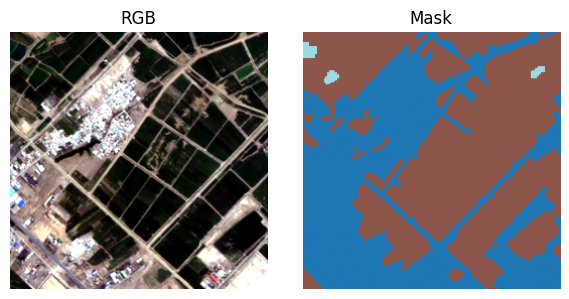

In [8]:
import importlib.metadata, sys, json, pathlib, random, math, collections
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Sampler, BatchSampler

# Ensure specific package versions if needed
def ensure_pkg(pkg, ver):
    try:
        cur = importlib.metadata.version(pkg)
        if cur != ver:
            print(f"[INFO] Updating {pkg} {cur} -> {ver}")
            get_ipython().system(f"pip install -q {pkg}=={ver}")
    except importlib.metadata.PackageNotFoundError:
        print(f"[INFO] Installing {pkg}=={ver}")
        get_ipython().system(f"pip install -q {pkg}=={ver}")

ensure_pkg("albumentations", "1.3.1")
ensure_pkg("opencv-python-headless", "4.10.0.84")

import albumentations as A
import cv2

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load manifest and metadata
with open(PATCH_ROOT/"splits.json", "r") as f:
    MF = json.load(f)

PATCH_ROOT_STR = MF["patch_root"]

# --- Define raw vs derived channels (edit to your real set & order) ---
RAW_BANDS = MF.get("raw_band_names", ["B2","B3","B4","B8","B11","B12"])  # only sensor bands stored in X[..., :ORIG_BANDS]
DERIVED_NAMES = MF.get("derived_names", ["NDVI","NDWI","MNDWI","EVI","AWEI_sh"])  # indices/features

# SELECTED_BANDS should be raw only
SELECTED_BANDS = list(RAW_BANDS)
ORIG_BANDS = len(SELECTED_BANDS)

# band_stats must match raw bands (used for per-band scaling)
BAND_STATS = MF["band_stats"]
if len(BAND_STATS) != ORIG_BANDS:
    # keep code robust if MF contains more stats than raw bands
    BAND_STATS = BAND_STATS[:ORIG_BANDS]
assert len(BAND_STATS) == ORIG_BANDS, "band_stats must match number of raw bands"

# Initial channel names = raw + derived (final fix happens after first batch via sanitize block)
CHANNEL_NAMES = RAW_BANDS + DERIVED_NAMES

# Augmentations (mild and RS-friendly)
train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.10, scale_limit=0.10, rotate_limit=15,
                       p=0.30, border_mode=cv2.BORDER_REFLECT_101),
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.25),
    A.GaussNoise(var_limit=(0.0, 0.002), p=0.20),
], p=1.0)

val_tf = None  # no augmentation for val/test

# Dataset for (H,W,C) numpy patches → (C,H,W) tensors
class PatchDataset(Dataset):
    """
    Loads patches and returns (x, y) where:
    - First ORIG_BANDS are scaled to [0,1] by p2–p98.
    - Indices (NDVI/NDWI/EVI) are kept as-is.
    """
    def __init__(self, uids, root_dir, orig_bands, band_stats, transform=None, mmap: bool=True):
        self.uids       = list(uids) if uids is not None else []
        self.root       = Path(root_dir)
        self.orig_bands = int(orig_bands)
        self.band_stats = list(band_stats)
        self.transform  = transform
        self.mmap       = mmap

    def __len__(self):
        return len(self.uids)

    def _load_pair(self, uid):
        x = np.load(self.root/"X"/f"{uid}.npy", mmap_mode='r' if self.mmap else None)
        y = np.load(self.root/"Y"/f"{uid}.npy", mmap_mode='r' if self.mmap else None).astype(np.uint8)
        return np.array(x), np.array(y)

    def _scale_orig_bands(self, x):
        x = x.copy()
        for c, (lo, hi) in enumerate(self.band_stats[:self.orig_bands]):
            denom = (hi - lo) if (hi - lo) > 1e-6 else 1.0
            x[..., c] = np.clip((x[..., c] - lo) / denom, 0.0, 1.0)
        return x

    def __getitem__(self, idx):
        uid = self.uids[idx]
        x, y = self._load_pair(uid)
        x = np.nan_to_num(x, nan=0.0)
        x_scaled = self._scale_orig_bands(x)
        if self.transform is not None:
            aug = self.transform(image=x_scaled, mask=y)
            x_scaled, y = aug["image"], aug["mask"]
        x_t = torch.from_numpy(np.transpose(x_scaled, (2, 0, 1))).float()
        y_t = torch.from_numpy(y.astype(np.int64))
        return x_t, y_t

# Build splits (with fallback if train is empty)
train_uids = MF.get("train", []) or []
val_uids   = MF.get("val", []) or []
test_uids  = MF.get("test", []) or []

if len(train_uids) == 0:
    pool = (val_uids or []) + (test_uids or [])
    if len(pool) > 0:
        print("[FALLBACK] No training patches; sampling from val/test.")
        random.shuffle(pool)
        take = max(1, int(0.5 * len(pool)))
        train_uids = pool[:take]
        MF["train"] = train_uids
    else:
        print("[ERROR] No patches available. Revisit patching thresholds.")

train_ds = PatchDataset(train_uids, PATCH_ROOT_STR, ORIG_BANDS, BAND_STATS, transform=train_tf) if len(train_uids)>0 else None
val_ds   = PatchDataset(val_uids,   PATCH_ROOT_STR, ORIG_BANDS, BAND_STATS, transform=val_tf)   if len(val_uids)>0   else None
test_ds  = PatchDataset(test_uids,  PATCH_ROOT_STR, ORIG_BANDS, BAND_STATS, transform=val_tf)  if len(test_uids)>0  else None

# Index patches containing a target class (e.g., water)
def list_indices_with_class(uids, cls_id=WATER):
    idx_pos, idx_neg = [], []
    yroot = Path(MF["patch_root"]) / "Y"
    for i, uid in enumerate(uids):
        y = np.load(yroot / f"{uid}.npy")
        (idx_pos if (y == cls_id).any() else idx_neg).append(i)
    return idx_pos, idx_neg

# Batch sampler that enforces a fraction of water patches
class BalancedWaterBatchSampler(BatchSampler):
    def __init__(self, idx_pos, idx_neg, batch_size, water_frac=0.5, epoch_batches=None, seed=42):
        assert batch_size >= 1
        self.idx_pos = list(idx_pos)
        self.idx_neg = list(idx_neg)
        self.bs      = int(batch_size)
        self.water_k = int(max(1, round(self.bs * float(water_frac))))
        self.other_k = self.bs - self.water_k
        self.epoch_batches = int(epoch_batches) if epoch_batches is not None else None
        self.rng = random.Random(seed)

    def __iter__(self):
        self.rng.shuffle(self.idx_pos)
        self.rng.shuffle(self.idx_neg)
        if self.epoch_batches is None:
            n = len(self.idx_pos) + len(self.idx_neg)
            self.epoch_batches = max(1, math.ceil(n / self.bs))
        pos_ptr, neg_ptr = 0, 0
        for _ in range(self.epoch_batches):
            batch = []
            for _ in range(self.water_k):
                if pos_ptr >= len(self.idx_pos):
                    if len(self.idx_pos) == 0: break
                    pos_ptr = 0; self.rng.shuffle(self.idx_pos)
                batch.append(self.idx_pos[pos_ptr] if len(self.idx_pos)>0 else None)
                pos_ptr += 1
            while len(batch) < self.bs:
                if neg_ptr >= len(self.idx_neg):
                    if len(self.idx_neg) == 0: break
                    neg_ptr = 0; self.rng.shuffle(self.idx_neg)
                batch.append(self.idx_neg[neg_ptr] if len(self.idx_neg)>0 else None)
                neg_ptr += 1
            batch = [b for b in batch if b is not None]
            if not batch: continue
            yield batch

    def __len__(self):
        if self.epoch_batches is not None:
            return self.epoch_batches
        n = len(self.idx_pos) + len(self.idx_neg)
        return max(1, math.ceil(n / self.bs))

# Build loaders with adaptive sampling
def build_loader_with_samplers(train_ds, val_ds, test_ds,
                               activate_balanced_if_frac_lt=0.20,
                               water_target_frac=0.50,
                               default_bs=8):
    num_workers  = 2 if torch.cuda.is_available() else 0
    pin_mem      = torch.cuda.is_available()
    persist_flag = num_workers > 0

    def safe_bs(n_items, default_bs=8):
        return max(1, min(default_bs, int(n_items))) if n_items and n_items > 0 else 1

    train_loader = []
    if (train_ds is not None) and (len(train_ds) > 0):
        idx_pos, idx_neg = list_indices_with_class(train_uids, WATER)
        water_frac = (len(idx_pos) / max(1, (len(idx_pos)+len(idx_neg))))
        bs = safe_bs(len(train_ds), default_bs=default_bs)

        if (len(idx_pos) > 0) and (water_frac < activate_balanced_if_frac_lt) and (bs >= 2):
            print(f"[SAMPLER] BalancedWaterBatchSampler | water_frac={water_frac:.3f} < {activate_balanced_if_frac_lt}")
            epoch_batches = math.ceil(len(train_uids) / bs)
            batch_sampler = BalancedWaterBatchSampler(idx_pos, idx_neg, batch_size=bs,
                                                      water_frac=water_target_frac,
                                                      epoch_batches=epoch_batches, seed=RANDOM_SEED)
            train_loader = DataLoader(train_ds, batch_sampler=batch_sampler,
                                      num_workers=num_workers, pin_memory=pin_mem,
                                      persistent_workers=persist_flag)
        else:
            if (len(idx_pos) > 0) and (water_frac < 0.35):
                print(f"[SAMPLER] WeightedRandomSampler | water_frac={water_frac:.3f}")
                weights = np.ones(len(train_uids), dtype=np.float32)
                for i in idx_pos: weights[i] = 3.0
                from torch.utils.data import WeightedRandomSampler
                sampler = WeightedRandomSampler(weights=weights, num_samples=len(train_uids), replacement=True)
                train_loader = DataLoader(train_ds, batch_size=bs, sampler=sampler, drop_last=False,
                                          num_workers=num_workers, pin_memory=pin_mem, persistent_workers=persist_flag)
            else:
                print(f"[SAMPLER] Plain shuffle | water_frac={water_frac:.3f}")
                train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, drop_last=False,
                                          num_workers=num_workers, pin_memory=pin_mem, persistent_workers=persist_flag)
    else:
        print("[WARN] Train dataset is empty.")

    val_bs  = safe_bs(len(val_ds)  if val_ds  is not None else 0, default_bs=default_bs)
    test_bs = safe_bs(len(test_ds) if test_ds is not None else 0, default_bs=default_bs)

    val_loader = (DataLoader(val_ds, batch_size=val_bs, shuffle=False, drop_last=False,
                             num_workers=num_workers, pin_memory=pin_mem, persistent_workers=persist_flag)
                  if (val_ds is not None and len(val_ds)>0) else [])

    test_loader = (DataLoader(test_ds, batch_size=test_bs, shuffle=False, drop_last=False,
                              num_workers=num_workers, pin_memory=pin_mem, persistent_workers=persist_flag)
                   if (test_ds is not None and len(test_ds)>0) else [])

    return train_loader, val_loader, test_loader

# Create data loaders
train_loader, val_loader, test_loader = build_loader_with_samplers(
    train_ds, val_ds, test_ds,
    activate_balanced_if_frac_lt=0.20,
    water_target_frac=0.50,
    default_bs=8
)

# Attach dataset metadata (bands / ROI / AOI) after loaders are built
# Short, defensive, and explicit so logs prove Iran ROI training.

# Bands list (fallback covers 16 channels: 11 bands + 5 indices)
try:
    bands_list = None
    if 'CHANNEL_NAMES' in globals():
        bands_list = CHANNEL_NAMES
    elif isinstance(MF.get('bands', None), list):
        bands_list = MF['bands']

    if bands_list is None:
        # Fallback example: tweak as needed to match your pipeline order
        bands_list = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12","SCL","NDVI","NDWI","NDBI","NDMI","DEM"]

    if train_ds is not None: train_ds.bands = bands_list
    if val_ds   is not None: val_ds.bands   = bands_list
    if test_ds  is not None: test_ds.bands  = bands_list
except Exception as e:
    print("[WARN] Could not set bands:", e)

# ROI names
try:
    roi_train = MF.get("roi_name_train", MF.get("roi_name", "Iran_ROI_Train"))
    roi_val   = MF.get("roi_name_val",   MF.get("roi_name", "Iran_ROI_Val"))
    roi_test  = MF.get("roi_name_test",  MF.get("roi_name", "Iran_ROI_Test"))
    if train_ds is not None: train_ds.roi_name = roi_train
    if val_ds   is not None: val_ds.roi_name   = roi_val
    if test_ds  is not None: test_ds.roi_name  = roi_test
except Exception as e:
    print("[WARN] Could not set ROI names:", e)

# AOI bounds (if present in MF)
try:
    if "aoi_bounds_train" in MF and train_ds is not None:
        train_ds.aoi_bounds = MF["aoi_bounds_train"]
    if "aoi_bounds_val" in MF and val_ds is not None:
        val_ds.aoi_bounds = MF["aoi_bounds_val"]
    if "aoi_bounds_test" in MF and test_ds is not None:
        test_ds.aoi_bounds = MF["aoi_bounds_test"]
except Exception as e:
    print("[WARN] Could not set AOI bounds:", e)

# DATASET/ROI AUDIT
try:
    print("Train samples:", len(train_ds) if train_ds is not None else 0,
          "Val samples:", len(val_ds) if val_ds is not None else 0)
    print("Bands:", getattr(train_ds, "bands", getattr(train_ds, "CHANNEL_NAMES", "unknown")) if train_ds is not None else "unknown")
    print("ROI train:", getattr(train_ds, "roi_name", getattr(train_ds, "aoi_name", "unknown")) if train_ds is not None else "unknown")
    print("ROI val:",   getattr(val_ds,   "roi_name", getattr(val_ds,   "aoi_name", "unknown")) if val_ds is not None else "unknown")
    if (train_ds is not None) and hasattr(train_ds, "aoi_bounds"):
        print("Train AOI bounds:", train_ds.aoi_bounds)
    if (val_ds is not None) and hasattr(val_ds, "aoi_bounds"):
        print("Val AOI bounds:", val_ds.aoi_bounds)
except Exception as e:
    print("[WARN] ROI audit failed:", e)

# Quick sanity checks
print(f"[INFO] DataLoaders → Train {len(train_loader)} | Val {len(val_loader)} | Test {len(test_loader)}")
if len(train_loader) > 0:
    xb, yb = next(iter(train_loader))

    print(f"[INFO] Batch X: {tuple(xb.shape)} dtype={xb.dtype} min={float(xb.min()):.3f} max={float(xb.max()):.3f}")
    print(f"[INFO] Batch y: {tuple(yb.shape)} classes={sorted(list(set(yb.cpu().numpy().ravel().tolist())))}")
    print(f"[INFO] Input channels: {xb.shape[1]} | original_bands={ORIG_BANDS} | indices={xb.shape[1]-ORIG_BANDS}")

    # Build exact band names (raw + derived) to match input channels
    derived_count = xb.shape[1] - ORIG_BANDS
    raw = list(SELECTED_BANDS)  # raw sensor bands only

    base_derived = ["NDVI", "NDWI", "MNDWI", "EVI", "AWEI_sh"]
    if derived_count > len(base_derived):
        base_derived += [f"IDX{i}" for i in range(1, derived_count - len(base_derived) + 1)]
    derived = base_derived[:derived_count]

    bands_list = raw + derived
    assert len(bands_list) == xb.shape[1], f"Expected {xb.shape[1]} names, got {len(bands_list)}"

    # Attach to datasets and print
    if train_ds is not None: train_ds.bands = bands_list
    if val_ds   is not None: val_ds.bands   = bands_list
    if test_ds  is not None: test_ds.bands  = bands_list
    print("Bands (final):", bands_list)

else:
    print("[WARN] Train loader is empty; adjust patching thresholds.")

# Class presence summary for each split
def summarize(uids):
    cnt = collections.Counter()
    yroot = Path(MF["patch_root"]) / "Y"
    for uid in uids:
        y = np.load(yroot/f"{uid}.npy")
        s = set(np.unique(y).tolist())
        if 2 in s: cnt["water_patches"] += 1
        if 1 in s: cnt["veg_patches"]   += 1
        if 0 in s: cnt["soil_patches"]  += 1
    cnt["total"] = len(uids)
    return cnt

print("TRAIN:", summarize(train_uids))
print("VAL  :", summarize(val_uids))
print("TEST :", summarize(test_uids))

# Optional quick plot (RGB + mask)
try:
    if len(train_loader) > 0:
        import matplotlib.pyplot as plt
        b4 = CHANNEL_NAMES.index("B4"); b3 = CHANNEL_NAMES.index("B3"); b2 = CHANNEL_NAMES.index("B2")
        rgb = np.transpose(xb[0, [b4, b3, b2]].cpu().numpy(), (1, 2, 0))
        plt.figure(figsize=(6,3))
        plt.subplot(1,2,1); plt.imshow(np.clip(rgb, 0, 1)); plt.title("RGB"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(yb[0].cpu().numpy(), cmap="tab20"); plt.title("Mask"); plt.axis("off")
        plt.tight_layout(); plt.show()
    else:
        print("[INFO] Skipping plot (empty train).")
except Exception as e:
    print("[WARN] Plot skipped:", e)


Cell 7 — Robust U-Net (BN/GN auto, light dropout, clean upsampling)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# WS Conv
class WSConv2d(nn.Conv2d):
    def forward(self, x):
        w = self.weight
        mean = w.mean(dim=(1,2,3), keepdim=True)
        std  = w.std (dim=(1,2,3), keepdim=True) + 1e-5
        w = (w - mean) / std
        return F.conv2d(x, w, self.bias, self.stride, self.padding, self.dilation, self.groups)

#  Norm helper
def make_norm(num_ch, use_gn=True, groups=8):
    return nn.GroupNorm(min(groups, num_ch), num_ch) if use_gn else nn.BatchNorm2d(num_ch)

# SE block
class SEBlock(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        mid = max(1, ch // r)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch, mid, 1),
            nn.SiLU(),
            nn.Conv2d(mid, ch, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return x * self.fc(x)

# Attention gate
class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.theta_x = nn.Conv2d(x_ch, inter_ch, 1, bias=False)
        self.phi_g   = nn.Conv2d(g_ch, inter_ch, 1, bias=False)
        self.psi     = nn.Conv2d(inter_ch, 1, 1)
        self.act, self.sig = nn.SiLU(), nn.Sigmoid()
    def forward(self, g, x):
        g_, x_ = self.phi_g(g), self.theta_x(x)
        if g_.shape[-2:] != x_.shape[-2:]:
            g_ = F.interpolate(g_, size=x_.shape[-2:], mode="bilinear", align_corners=False)
        a = self.sig(self.psi(self.act(g_ + x_)))
        return x * a

# Conv-Norm-Act
class ConvNormAct(nn.Module):
    def __init__(self, in_ch, out_ch, use_gn=True, use_ws=True):
        super().__init__()
        Conv = WSConv2d if use_ws else nn.Conv2d
        self.conv = Conv(in_ch, out_ch, 3, padding=1, bias=False)
        self.norm = make_norm(out_ch, use_gn)
        self.act  = nn.SiLU()
    def forward(self, x): return self.act(self.norm(self.conv(x)))

# Double conv
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, use_gn=True, use_ws=True, use_se=True):
        super().__init__()
        self.block = nn.Sequential(
            ConvNormAct(in_ch, out_ch, use_gn, use_ws),
            ConvNormAct(out_ch, out_ch, use_gn, use_ws),
        )
        self.se = SEBlock(out_ch) if use_se else nn.Identity()
    def forward(self, x): return self.se(self.block(x))

# Down block
class Down(nn.Module):
    def __init__(self, in_ch, out_ch, use_gn=True, use_ws=True, use_se=True):
        super().__init__()
        self.pool, self.conv = nn.MaxPool2d(2), DoubleConv(in_ch, out_ch, use_gn, use_ws, use_se)
    def forward(self, x): return self.conv(self.pool(x))

# Up block
class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, use_gn=True, use_ws=True, use_se=True, p_drop=0.0):
        super().__init__()
        Conv = WSConv2d if use_ws else nn.Conv2d
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            Conv(in_ch, in_ch//2, 1, bias=False),
        )
        inter_ch = max(1, out_ch//2)
        self.att  = AttentionGate(in_ch//2, skip_ch, inter_ch)
        self.conv = DoubleConv(in_ch//2 + skip_ch, out_ch, use_gn, use_ws, use_se)
        self.drop = nn.Dropout2d(p_drop) if p_drop>0 else nn.Identity()
    def forward(self, x, skip):
        x = self.up(x)
        skip = self.att(x, skip)
        dh, dw = skip.shape[-2]-x.shape[-2], skip.shape[-1]-x.shape[-1]
        if dh!=0 or dw!=0:
            x = F.pad(x, (0,max(dw,0),0,max(dh,0)))
            x = x[..., :skip.shape[-2], :skip.shape[-1]]
        x = torch.cat([skip, x], 1)
        return self.drop(self.conv(x))

# U-Net
class WaterAwareUNet(nn.Module):
    def __init__(self, in_channels, num_classes, base=32,
                 use_gn=True, use_ws=True, use_se=True, dec_dropout=0.1):
        super().__init__()
        b = base
        self.enc1 = DoubleConv(in_channels, b, use_gn, use_ws, use_se)
        self.enc2 = Down(b, b*2, use_gn, use_ws, use_se)
        self.enc3 = Down(b*2, b*4, use_gn, use_ws, use_se)
        self.enc4 = Down(b*4, b*8, use_gn, use_ws, use_se)
        self.bott = DoubleConv(b*8, b*16, use_gn, use_ws, use_se)
        self.up4  = Up(b*16, b*8, b*8, use_gn, use_ws, use_se, dec_dropout)
        self.up3  = Up(b*8, b*4, b*4, use_gn, use_ws, use_se, dec_dropout)
        self.up2  = Up(b*4, b*2, b*2, use_gn, use_ws, use_se, dec_dropout/2)
        self.up1  = Up(b*2, b,   b,   use_gn, use_ws, use_se, dec_dropout/4)
        self.head = nn.Conv2d(b, num_classes, 1)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Conv2d, WSConv2d)):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
            if m.weight is not None: nn.init.ones_(m.weight)
            if m.bias   is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b  = self.bott(e4)
        d4 = self.up4(b, e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)
        return self.head(d1)

# Build model
IN_CHANNELS = next(iter(train_loader))[0].shape[1]
NUM_CLASSES = len(CLASS_NAMES)
BASE_CH = 32

model = WaterAwareUNet(IN_CHANNELS, NUM_CLASSES, BASE_CH, True, True, True, 0.1).to(DEVICE)

# Model summary log
print(f"[INFO] Model → in={IN_CHANNELS}, classes={NUM_CLASSES}, base={BASE_CH}, "
      f"params={sum(p.numel() for p in model.parameters())/1e6:.2f}M")

# Trainable check (prove training vs inference)
for n, p in model.named_parameters():
    print(f"{n:60s} trainable={p.requires_grad}")
print("Trainable params:",
      sum(p.numel() for p in model.parameters() if p.requires_grad),
      "/ Total:",
      sum(p.numel() for p in model.parameters()))

# Optional: channel consistency (only if bands metadata exists here)
if getattr(train_ds, "bands", None):
    assert len(train_ds.bands) == IN_CHANNELS, \
        f"Mismatch: len(train_ds.bands)={len(train_ds.bands)} vs IN_CHANNELS={IN_CHANNELS}"


[INFO] Model → in=16, classes=3, base=32, params=7.44M
enc1.block.0.conv.weight                                     trainable=True
enc1.block.0.norm.weight                                     trainable=True
enc1.block.0.norm.bias                                       trainable=True
enc1.block.1.conv.weight                                     trainable=True
enc1.block.1.norm.weight                                     trainable=True
enc1.block.1.norm.bias                                       trainable=True
enc1.se.fc.1.weight                                          trainable=True
enc1.se.fc.1.bias                                            trainable=True
enc1.se.fc.3.weight                                          trainable=True
enc1.se.fc.3.bias                                            trainable=True
enc2.conv.block.0.conv.weight                                trainable=True
enc2.conv.block.0.norm.weight                                trainable=True
enc2.conv.block.0.norm.bias      

Cell 8 — Training (timing + weight clamp + scheduler fallback)

[INFO] Class weights: [1.0, 1.0, 10.0]


/tmp/ipython-input-2331701948.py:56: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


[OPTIM] group 0: lr=4.00e-05, weight_decay=0.0001 params=112
[RUNCFG] {'in_channels': 16, 'num_classes': 3, 'base_ch': 32, 'optimizer': 'AdamW', 'lr': 0.001, 'epochs': 30, 'weight_decay': 0.0001, 'scheduler': 'OneCycleLR', 'use_amp': True, 'roi_train': 'Iran_ROI_Train', 'roi_val': 'Iran_ROI_Val', 'bands': ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'EVI', 'AWEI_sh', 'IDX1', 'IDX2', 'IDX3', 'IDX4', 'IDX5']}


Epoch 1/30:   0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipython-input-2331701948.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 11/11 [00:09<00:00,  1.21it/s, loss=13.4302, lr=2.94e-04]
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args.

[E01] train=1.8239 val=1.7766 acc=0.521 mIoU=0.267 F1=0.388 Kappa=0.152 epoch=10.3s batch≈717.1ms
[INFO] New BEST saved.


...

[E28] train=0.1585 val=0.1643 acc=0.962 mIoU=0.923 F1=0.960 Kappa=0.924 epoch=8.1s batch≈354.6ms


Epoch 29/30:   0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipython-input-2331701948.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 29/30: 100%|██████████| 11/11 [00:05<00:00,  1.90it/s, loss=1.1919, lr=2.80e-06]
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args

[E29] train=0.1619 val=0.1643 acc=0.962 mIoU=0.923 F1=0.960 Kappa=0.924 epoch=6.9s batch≈332.9ms
[INFO] New BEST saved.


Epoch 30/30:   0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipython-input-2331701948.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 30/30: 100%|██████████| 11/11 [00:06<00:00,  1.73it/s, loss=1.1618, lr=3.20e-08]
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-2331701948.py:164: FutureWarning: `torch.cuda.amp.autocast(args

[E30] train=0.1578 val=0.1643 acc=0.962 mIoU=0.923 F1=0.960 Kappa=0.924 epoch=7.4s batch≈336.6ms
[INFO] New BEST saved.
[INFO] Training done. Best mIoU = 0.9230


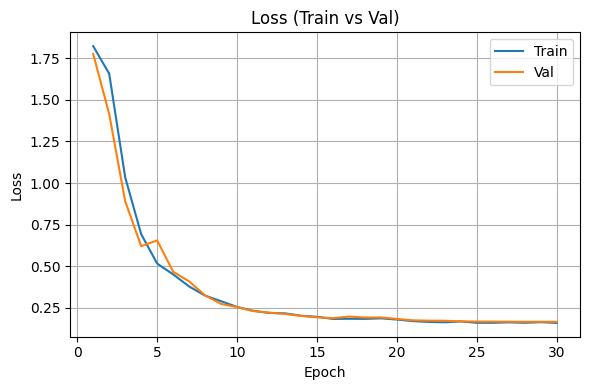

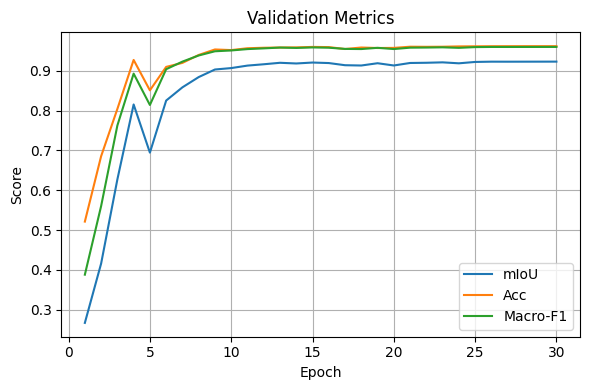

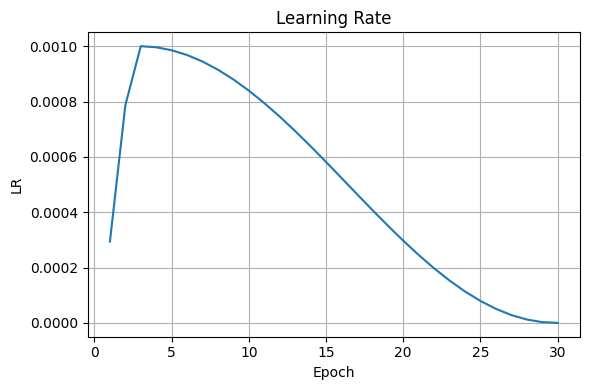

/tmp/ipython-input-2331701948.py:246: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipython-input-2331701948.py:246: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipython-input-2331701948.py:246: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipython-input-2331701948.py:246: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


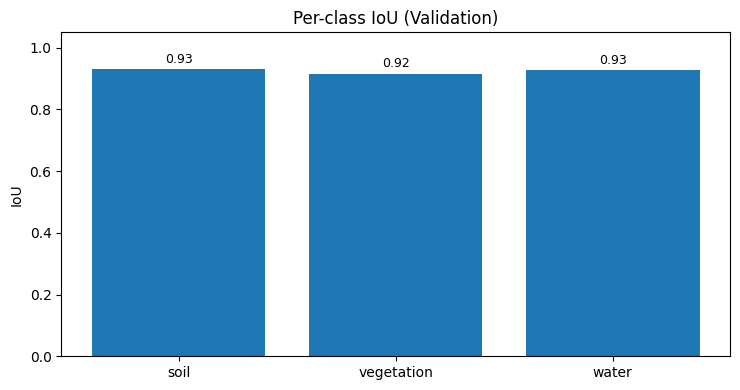

/tmp/ipython-input-2331701948.py:281: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):


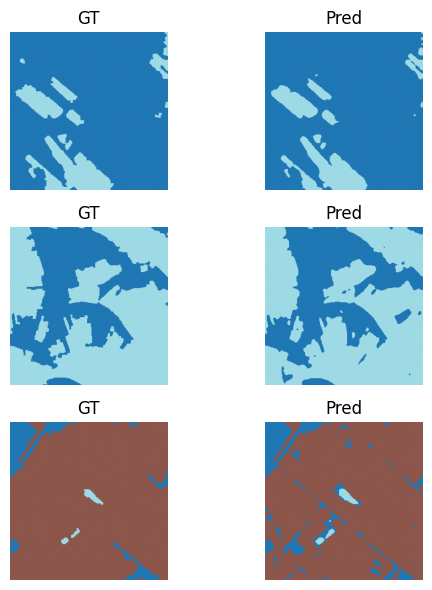

In [11]:
import time, json
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# seeds
torch.manual_seed(42); np.random.seed(42)
if DEVICE.type == "cuda": torch.cuda.manual_seed_all(42)

# training params
LR, EPOCHS, MAX_NORM, PATIENCE = 1e-3, 30, 1.0, 8
BPE = max(1, len(train_loader))

# class weights from manifest
ratios = MF["class_pixel_ratio"]
weights = []
for k in range(NUM_CLASSES):
    rec = ratios.get(str(k), ratios.get(k, {"pct": 0.0}))
    pct = float(rec["pct"])/100.0 if isinstance(rec, dict) else float(rec)
    pct = max(pct, 1e-6)
    weights.append(1.0/pct)
weights = [float(np.clip(w, 1.0, 10.0)) for w in weights]
class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
print("[INFO] Class weights:", weights)

# losses
def dice_loss(logits, targets, eps=1e-6):
    C = logits.shape[1]
    probs  = torch.softmax(logits, 1)
    onehot = torch.nn.functional.one_hot(targets, C).permute(0,3,1,2).float()
    num = 2*(probs*onehot).sum((0,2,3))
    den = (probs+onehot).sum((0,2,3)) + eps
    return 1.0 - (num/den).mean()

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None, dice_w=1.0, ce_w=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dw, self.cw = dice_w, ce_w
    def forward(self, logits, targets):
        return self.cw*self.ce(logits, targets) + self.dw*dice_loss(logits, targets)

loss_fn = CombinedLoss(class_weights=class_weights)

# optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = (torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, epochs=EPOCHS,
                                                 steps_per_epoch=BPE, pct_start=0.1)
             if BPE >= 3 else
             torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS))

# amp
use_amp = (DEVICE.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# optim log
for i, g in enumerate(optimizer.param_groups):
    print(f"[OPTIM] group {i}: lr={g['lr']:.2e}, weight_decay={g.get('weight_decay',0)} params={len(g['params'])}")

# run config snapshot
run_cfg = {
    "in_channels": IN_CHANNELS,
    "num_classes": NUM_CLASSES,
    "base_ch": BASE_CH,
    "optimizer": "AdamW",
    "lr": LR, "epochs": EPOCHS, "weight_decay": 1e-4,
    "scheduler": type(scheduler).__name__,
    "use_amp": use_amp,
    "roi_train": getattr(train_ds, "roi_name", "unknown"),
    "roi_val": getattr(val_ds, "roi_name", "unknown"),
    "bands": getattr(train_ds, "bands", None),
}
print("[RUNCFG]", run_cfg)

# io
CKPT_DIR = RUN_ROOT/"checkpoints"; CKPT_DIR.mkdir(parents=True, exist_ok=True)
GRAD_DIR = RUN_ROOT/"gradients";  GRAD_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR  = RUN_ROOT/"logs";       LOG_DIR.mkdir(parents=True, exist_ok=True)
log_path = LOG_DIR/"train_log.jsonl"; open(log_path,"w").close()
log_csv  = LOG_DIR/"train_log.csv"; open(log_csv,"w").write(
    "epoch,train_loss,val_loss,acc,miou,macro_f1,kappa,lr,epoch_sec,batch_ms\n"
)

# ckpt helpers
def save_checkpoint(tag, epoch, best_miou):
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "in_channels": IN_CHANNELS, "num_classes": NUM_CLASSES, "base_ch": BASE_CH,
        "best_miou": float(best_miou),
    }, CKPT_DIR/f"{tag}.pt")

def save_gradients(epoch, batch_idx):
    grads = {n: p.grad.detach().cpu().half() for n,p in model.named_parameters() if p.grad is not None}
    torch.save({"epoch":epoch,"batch":batch_idx,"grads":grads}, GRAD_DIR/f"epoch{epoch:03d}_batch{batch_idx:03d}.pt")

# metrics
@torch.no_grad()
def evaluate_metrics(logits, targets, num_classes=NUM_CLASSES):
    preds = torch.argmax(logits, 1).cpu().numpy()
    t     = targets.cpu().numpy()
    cm = confusion_matrix(t.ravel(), preds.ravel(), labels=list(range(num_classes)))
    acc = (np.diag(cm).sum() / cm.sum()) if cm.sum()>0 else 0.0
    iou = np.diag(cm) / (cm.sum(1)+cm.sum(0)-np.diag(cm)+1e-6)
    miou = float(np.nanmean(iou))
    prec = np.diag(cm)/(cm.sum(0)+1e-6)
    rec  = np.diag(cm)/(cm.sum(1)+1e-6)
    f1   = 2*prec*rec/(prec+rec+1e-6)
    macro_f1 = float(np.nanmean(f1))
    pe = (cm.sum(0)*cm.sum(1)).sum()/(cm.sum()**2 + 1e-6)
    kappa = float((acc-pe)/(1-pe+1e-6))
    return acc, miou, macro_f1, kappa

# train
best_miou, epochs_no_improve = -1.0, 0
val_loader_eff = val_loader if val_loader else test_loader

for epoch in range(1, EPOCHS+1):
    t_epoch = time.time()
    model.train(); running, n_batches, t_batch_total = 0.0, 0, 0.0
    pbar = tqdm(enumerate(train_loader,1), total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS}")

    for bi,(xb,yb) in pbar:
        t_b0 = time.time()
        xb,yb = xb.to(DEVICE,non_blocking=True), yb.to(DEVICE,non_blocking=True)

        # check channels once
        if bi == 1 and getattr(train_ds, "bands", None):
            assert len(train_ds.bands) == xb.shape[1], \
                f"Mismatch: len(train_ds.bands)={len(train_ds.bands)} vs input channels={xb.shape[1]}"

        optimizer.zero_grad(set_to_none=True)
        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(xb); loss = loss_fn(logits, yb)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
        else:
            logits = model(xb); loss = loss_fn(logits, yb); loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)

        if bi == 1: save_gradients(epoch, bi)

        if use_amp: scaler.step(optimizer); scaler.update()
        else: optimizer.step()
        scheduler.step()

        running += float(loss.item())*xb.size(0)
        n_batches += 1; t_batch_total += (time.time()-t_b0)
        pbar.set_postfix(loss=f"{running/(bi*xb.size(0)):.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    train_loss = running / max(len(train_loader.dataset), 1)

    # validate
    model.eval(); val_running=0.0; accs=[]; mious=[]; f1s=[]; kappas=[]
    for xb,yb in val_loader_eff:
        xb,yb = xb.to(DEVICE,non_blocking=True), yb.to(DEVICE,non_blocking=True)
        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(xb); loss = loss_fn(logits, yb)
        else:
            logits = model(xb); loss = loss_fn(logits, yb)
        val_running += float(loss.item())*xb.size(0)
        a,m,f,k = evaluate_metrics(logits, yb)
        accs.append(a); mious.append(m); f1s.append(f); kappas.append(k)

    val_loss = val_running / max(len(val_loader_eff.dataset), 1)
    acc, miou = float(np.mean(accs)), float(np.mean(mious))
    mf1, kap  = float(np.mean(f1s)), float(np.mean(kappas))
    epoch_sec = time.time()-t_epoch
    batch_ms  = (t_batch_total/max(n_batches,1))*1000.0

    rec = {"epoch":epoch,"train_loss":train_loss,"val_loss":val_loss,"acc":acc,"mIoU":miou,"macro_f1":mf1,"kappa":kap,
           "lr":float(optimizer.param_groups[0]["lr"]), "epoch_sec":epoch_sec,"batch_ms":batch_ms}
    with open(log_path,"a") as f: f.write(json.dumps(rec)+"\n")
    with open(log_csv,"a") as f:
        f.write(f"{epoch},{train_loss:.6f},{val_loss:.6f},{acc:.6f},{miou:.6f},{mf1:.6f},{kap:.6f},"
                f"{optimizer.param_groups[0]['lr']:.6e},{epoch_sec:.2f},{batch_ms:.2f}\n")

    print(f"[E{epoch:02d}] train={train_loss:.4f} val={val_loss:.4f} acc={acc:.3f} mIoU={miou:.3f} "
          f"F1={mf1:.3f} Kappa={kap:.3f} epoch={epoch_sec:.1f}s batch≈{batch_ms:.1f}ms")

    save_checkpoint("last", epoch, best_miou)
    if miou > best_miou + 1e-6:
        best_miou = miou
        epochs_no_improve = 0
        save_checkpoint("best", epoch, best_miou)
        print("[INFO] New BEST saved.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"[EARLY STOP] best mIoU = {best_miou:.4f}")
            break

print(f"[INFO] Training done. Best mIoU = {best_miou:.4f}")

# plots and extra eval
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv(log_csv)

# plot losses
plt.figure(figsize=(6,4))
plt.plot(df["epoch"], df["train_loss"], label="Train")
plt.plot(df["epoch"], df["val_loss"],   label="Val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss (Train vs Val)")
plt.grid(True); plt.legend()
plt.tight_layout(); plt.savefig(LOG_DIR/"plot_loss.png", dpi=180)
plt.show()

# plot val metrics
plt.figure(figsize=(6,4))
plt.plot(df["epoch"], df["miou"],     label="mIoU")
plt.plot(df["epoch"], df["acc"],      label="Acc")
plt.plot(df["epoch"], df["macro_f1"], label="Macro-F1")
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("Validation Metrics")
plt.grid(True); plt.legend()
plt.tight_layout(); plt.savefig(LOG_DIR/"plot_val_metrics.png", dpi=180)
plt.show()

# plot LR
plt.figure(figsize=(6,4))
plt.plot(df["epoch"], df["lr"])
plt.xlabel("Epoch"); plt.ylabel("LR"); plt.title("Learning Rate")
plt.grid(True)
plt.tight_layout(); plt.savefig(LOG_DIR/"plot_lr.png", dpi=180)
plt.show()

# per-class IoU on validation
@torch.no_grad()
def compute_cm_on_loader(model, loader, num_classes):
    from sklearn.metrics import confusion_matrix
    model.eval()
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(xb)
        preds = torch.argmax(logits, 1)
        y_np = yb.cpu().numpy().ravel()
        p_np = preds.cpu().numpy().ravel()
        cm = confusion_matrix(y_np, p_np, labels=list(range(num_classes)))
        cm_total += cm
    return cm_total

if len(val_loader_eff) > 0:
    cm_val = compute_cm_on_loader(model, val_loader_eff, NUM_CLASSES)
    diag = np.diag(cm_val).astype(np.float32)
    denom = (cm_val.sum(1) + cm_val.sum(0) - np.diag(cm_val)).astype(np.float32) + 1e-6
    iou_per_class = diag / denom
    cls_names = [str(i) for i in range(NUM_CLASSES)]
    try:
        if isinstance(CLASS_NAMES, (list, tuple)) and len(CLASS_NAMES) == NUM_CLASSES:
            cls_names = list(CLASS_NAMES)
    except:
        pass
    plt.figure(figsize=(7.5,4))
    plt.bar(range(NUM_CLASSES), iou_per_class)
    plt.xticks(range(NUM_CLASSES), cls_names)
    plt.ylabel("IoU"); plt.title("Per-class IoU (Validation)")
    for i,v in enumerate(iou_per_class):
        plt.text(i, v+0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.ylim(0, 1.05)
    plt.tight_layout(); plt.savefig(LOG_DIR/"plot_per_class_iou.png", dpi=180)
    plt.show()

# qualitative samples from validation
try:
    if len(val_loader_eff) > 0:
        xb, yb = next(iter(val_loader_eff))
        xb = xb.to(DEVICE, non_blocking=True)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(xb)
        preds = logits.argmax(1).cpu().numpy()
        gt    = yb.cpu().numpy()
        n_show = min(3, xb.shape[0])
        fig, axs = plt.subplots(n_show, 2, figsize=(6, 2*n_show))
        if n_show == 1: axs = np.array([axs])
        for i in range(n_show):
            axs[i,0].imshow(gt[i], cmap="tab20");    axs[i,0].set_title("GT");   axs[i,0].axis("off")
            axs[i,1].imshow(preds[i], cmap="tab20"); axs[i,1].set_title("Pred"); axs[i,1].axis("off")
        plt.tight_layout(); plt.savefig(LOG_DIR/"plot_qualitative_val.png", dpi=180)
        plt.show()
except Exception as e:
    print("[WARN] Qualitative plot skipped:", e)


Cell 9 — Evaluation: Acc, per-class IoU/Prec/Rec, mIoU, Macro-F1, Kappa + Plots

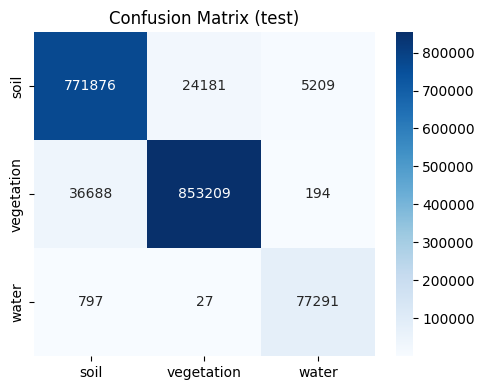

[SAVED] /content/drive/MyDrive/AgriSeg/runs/eval/confusion_matrix_test.png


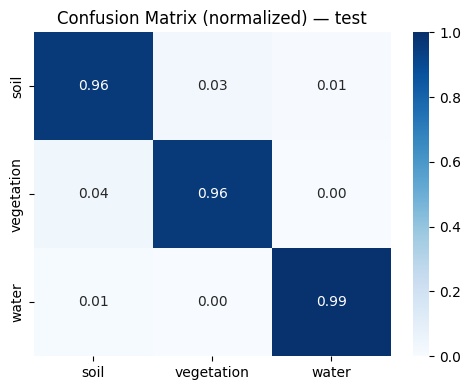

[SAVED] /content/drive/MyDrive/AgriSeg/runs/eval/confusion_matrix_norm_test.png


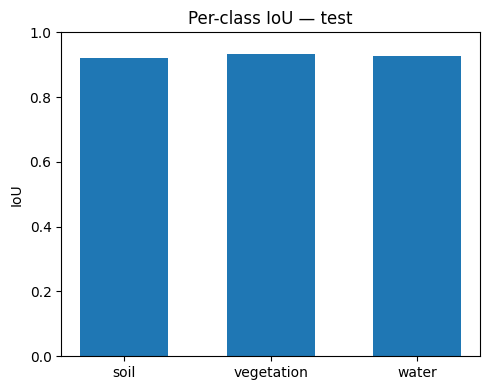

[SAVED] /content/drive/MyDrive/AgriSeg/runs/eval/per_class_iou_test.png
=== Metrics ===
Pixel Acc : 0.9621
Mean IoU  : 0.9263 | FWIoU: 0.9270
Macro F1  : 0.9617
Macro P/R : 0.9536 / 0.9704
Kappa     : 0.9300
       soil → IoU=0.9203
 vegetation → IoU=0.9332
      water → IoU=0.9254


In [12]:
!pip -q install seaborn==0.13.2

import json, numpy as np, torch
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

# save dir
EVAL_DIR = (RUN_ROOT / "eval")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# optional pandas
try:
    import pandas as pd
    _HAS_PANDAS = True
except Exception:
    _HAS_PANDAS = False

@torch.no_grad()
def evaluate_model(model, dataloader, device, class_names, tag="test", water_class_name="water"):
    # setup
    model.eval()
    if len(dataloader) == 0:
        raise RuntimeError("[ERROR] Empty dataloader.")

    C = len(class_names)
    labels = list(range(C))
    try:
        WATER_ID = class_names.index(water_class_name)
    except ValueError:
        WATER_ID = C - 1

    # collect preds
    y_true_all, y_pred_all, y_prob_water_all = [], [], []
    for xb, yb in dataloader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)
        preds  = torch.argmax(probs, dim=1)
        y_true_all.append(yb.detach().cpu().numpy().ravel())
        y_pred_all.append(preds.detach().cpu().numpy().ravel())
        y_prob_water_all.append(probs[:, WATER_ID].detach().cpu().numpy().ravel())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    pw     = np.concatenate(y_prob_water_all)

    # drop -1 labels
    vm = y_true >= 0
    if not np.all(vm):
        y_true, y_pred, pw = y_true[vm], y_pred[vm], pw[vm]

    # metrics
    cm  = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    inter = np.diag(cm).astype(float)
    union = cm.sum(1) + cm.sum(0) - inter
    iou  = np.divide(inter, np.maximum(union, 1e-6), out=np.zeros_like(inter, float), where=(union > 0))
    miou = float(np.nanmean(iou))

    freq  = cm.sum(1) / max(cm.sum(), 1)
    fwiou = float(np.nansum(freq * iou))

    macro_f1   = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    macro_prec = precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    macro_rec  = recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

    total = cm.sum()
    pe = (cm.sum(0) * cm.sum(1)).sum() / (total**2 + 1e-6) if total > 0 else 0.0
    kappa = float((acc - pe) / (1 - pe + 1e-6)) if (1 - pe) > 0 else 0.0

    prec_per = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    rec_per  = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

    # water diagnostics (no plots)
    y_water_true = (y_true == WATER_ID).astype(np.uint8)
    try: water_ap  = float(average_precision_score(y_water_true, pw))
    except Exception: water_ap = float('nan')
    try: water_auc = float(roc_auc_score(y_water_true, pw))
    except Exception: water_auc = float('nan')

    # save JSON
    metrics_json = {
        "tag": tag,
        "class_names": class_names,
        "pixel_accuracy": float(acc),
        "mean_iou": float(miou),
        "fw_iou": float(fwiou),
        "macro_f1": float(macro_f1),
        "macro_precision": float(macro_prec),
        "macro_recall": float(macro_rec),
        "kappa": float(kappa),
        "per_class": {
            class_names[i]: {
                "IoU": float(iou[i]),
                "precision": float(prec_per[i]),
                "recall": float(rec_per[i]),
                "support": int(cm[i].sum()),
            } for i in labels
        },
        "confusion_matrix": cm.tolist(),
        "confusion_matrix_norm": (cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)).tolist(),
        "water_diagnostics": {"class_id": int(WATER_ID), "AP": water_ap, "ROC_AUC": water_auc}
    }
    with open(EVAL_DIR / f"metrics_{tag}.json", "w") as f:
        json.dump(metrics_json, f, indent=2)

    # optional CSV
    if _HAS_PANDAS:
        rows = [{"class": class_names[i], "IoU": float(iou[i]),
                 "precision": float(prec_per[i]), "recall": float(rec_per[i]),
                 "support": int(cm[i].sum())} for i in labels]
        pd.DataFrame(rows).to_csv(EVAL_DIR / f"per_class_{tag}.csv", index=False)

    # Confusion Matrix (count)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix ({tag})")
    plt.tight_layout()
    path_cm = EVAL_DIR / f"confusion_matrix_{tag}.png"
    plt.savefig(path_cm, dpi=300)
    plt.show(); plt.close()
    print(f"[SAVED] {path_cm}")

    # Confusion Matrix (normalized)
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(5,4))
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, vmin=0, vmax=1)
    plt.title(f"Confusion Matrix (normalized) — {tag}")
    plt.tight_layout()
    path_cmn = EVAL_DIR / f"confusion_matrix_norm_{tag}.png"
    plt.savefig(path_cmn, dpi=300)
    plt.show(); plt.close()
    print(f"[SAVED] {path_cmn}")

    # Per-class IoU
    plt.figure(figsize=(5,4))
    plt.bar(class_names, iou, width=0.6)
    plt.ylim(0, 1)
    plt.ylabel("IoU")
    plt.title(f"Per-class IoU — {tag}")
    plt.tight_layout()
    path_iou = EVAL_DIR / f"per_class_iou_{tag}.png"
    plt.savefig(path_iou, dpi=300)
    plt.show(); plt.close()
    print(f"[SAVED] {path_iou}")

    # print summary
    print("=== Metrics ===")
    print(f"Pixel Acc : {acc:.4f}")
    print(f"Mean IoU  : {miou:.4f} | FWIoU: {fwiou:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print(f"Macro P/R : {macro_prec:.4f} / {macro_rec:.4f}")
    print(f"Kappa     : {kappa:.4f}")
    for i, cn in enumerate(class_names):
        print(f"{cn:>11s} → IoU={iou[i]:.4f}")

    return metrics_json, cm, iou

# run
_ = evaluate_model(model, test_loader, DEVICE, CLASS_NAMES, tag="test")


Cell 10 — Qualitative samples: RGB | GT | Prediction

[SKIP] Sample 0 skipped.


/tmp/ipython-input-3535712642.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_p = Image.fromarray(mask_np.astype(np.uint8), mode="P")


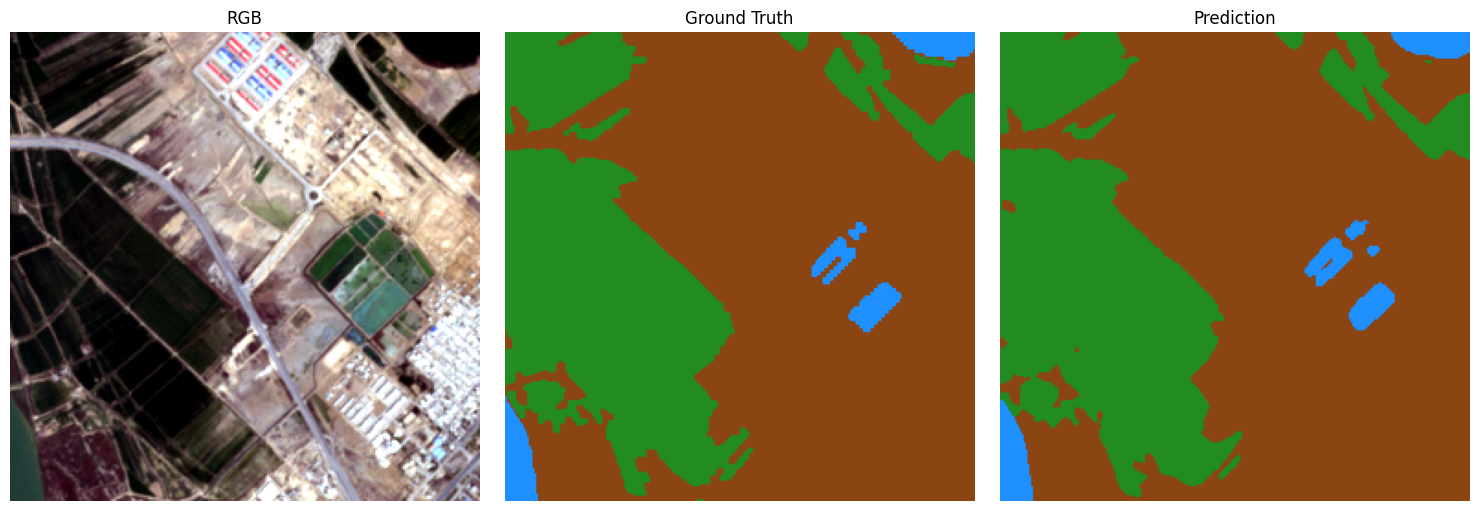

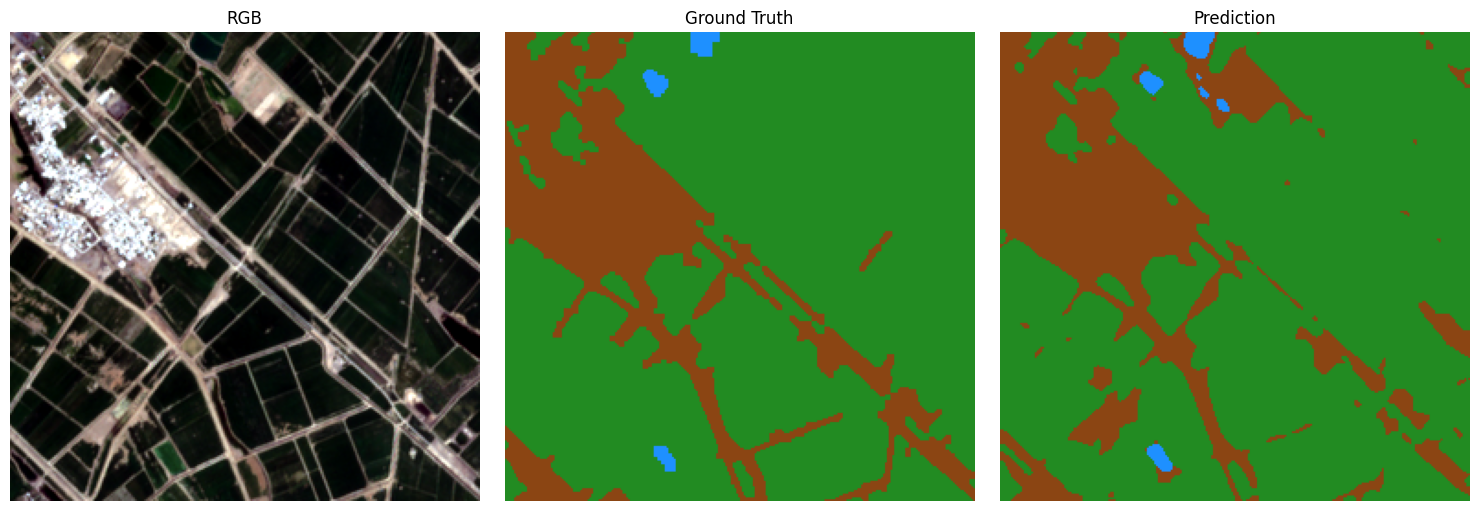

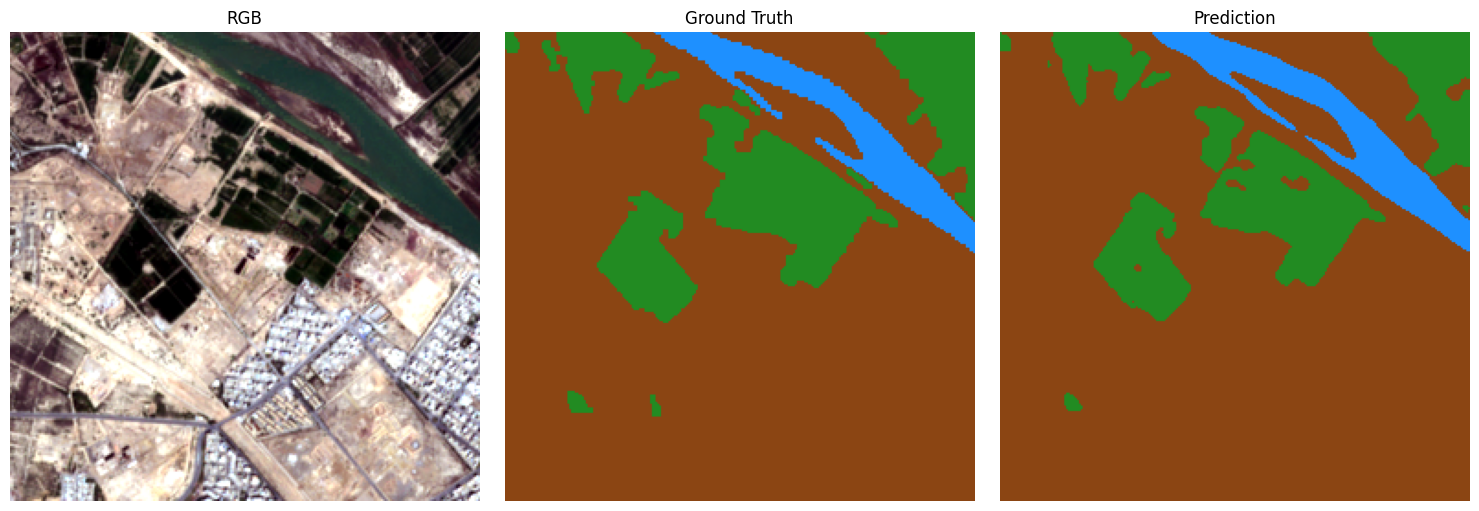

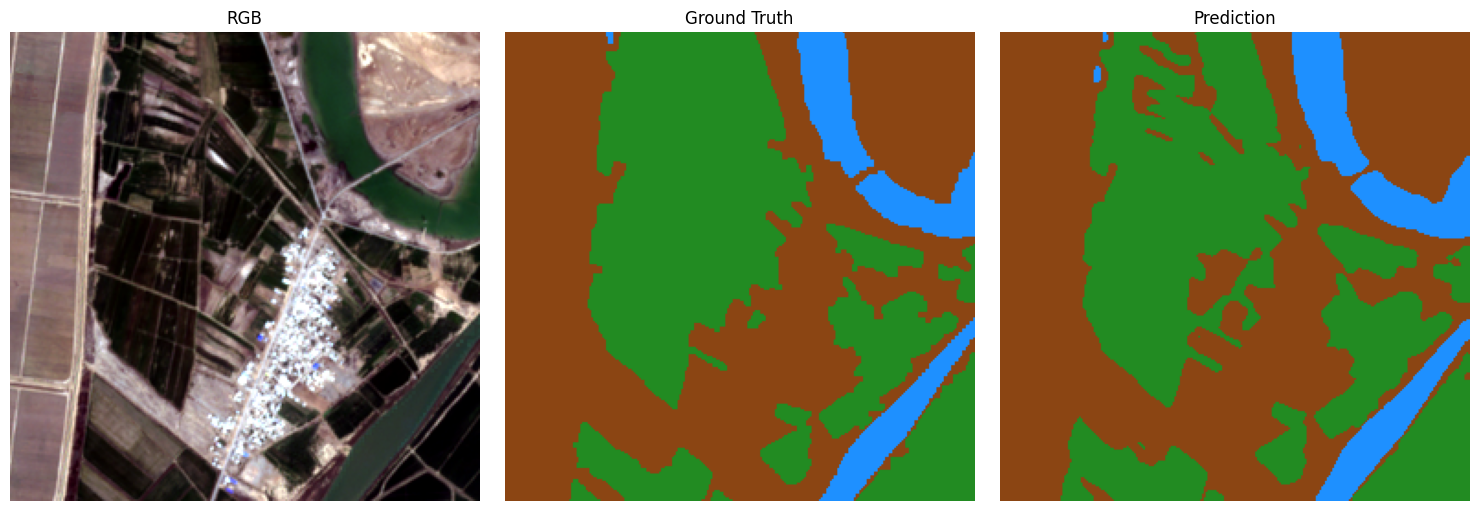

In [13]:
# Show samples; skip if not valid
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

SAMPLES_DIR = RUN_ROOT / "samples"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

random.seed(42)

def mask_to_rgb(mask_np: np.ndarray) -> np.ndarray:
    # map class ids to RGB
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for k, color in PALETTE_RGB.items():
        rgb[mask_np == k] = color
    return rgb

def save_indexed_png(mask_np: np.ndarray, out_path):
    # save mask as indexed PNG with palette
    pal = [0] * 768
    for cls, (r, g, b) in PALETTE_RGB.items():
        pal[cls*3:cls*3+3] = [r, g, b]
    img_p = Image.fromarray(mask_np.astype(np.uint8), mode="P")
    img_p.putpalette(pal)
    img_p.save(out_path, optimize=True)

def get_water_id(class_names, fallback=WATER):
    # resolve water class id safely
    try:
        return class_names.index("water")
    except ValueError:
        return fallback

@torch.no_grad()
def plot_one_sample(ds, idx, save=True):
    # forward + visualize one sample (RGB / GT / Prediction)
    model.eval()
    x, y = ds[idx]
    logits = model(x.unsqueeze(0).to(DEVICE))
    probs  = torch.softmax(logits, dim=1)
    pred   = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()

    # RGB from bands B4,B3,B2
    rgb = x[[2,1,0], ...].permute(1,2,0).cpu().numpy()
    rgb_8u = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)

    gt_np   = y.numpy() if torch.is_tensor(y) else y
    gt_rgb  = mask_to_rgb(gt_np)
    pr_rgb  = mask_to_rgb(pred)

    base = f"sample_{idx:04d}"
    if save:
        Image.fromarray(rgb_8u).save(SAMPLES_DIR / f"{base}_rgb.png")
        Image.fromarray(gt_rgb).save(SAMPLES_DIR / f"{base}_gt.png")
        Image.fromarray(pr_rgb).save(SAMPLES_DIR / f"{base}_pred.png")
        save_indexed_png(gt_np, SAMPLES_DIR / f"{base}_gt_idx.png")
        save_indexed_png(pred,  SAMPLES_DIR / f"{base}_pred_idx.png")

    # show 3 panels
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(rgb_8u); axs[0].set_title("RGB"); axs[0].axis("off")
    axs[1].imshow(gt_rgb); axs[1].set_title("Ground Truth"); axs[1].axis("off")
    axs[2].imshow(pr_rgb); axs[2].set_title("Prediction"); axs[2].axis("off")
    plt.tight_layout(); plt.show()

# pick same evenly spaced indices as before, then apply a light sanity filter
N = min(5, len(test_ds))
if N == 0:
    print("[WARN] test_ds is empty; skipping samples.")
else:
    idxs = np.linspace(0, len(test_ds) - 1, N, dtype=int).tolist()
    water_id = get_water_id(CLASS_NAMES, fallback=WATER)

    for i in idxs:
        # basic sanity check: skip masks with no positive pixels for the target id
        _, y = test_ds[i]
        y_np = y.numpy() if torch.is_tensor(y) else y
        if not (y_np == water_id).any():
            print(f"[SKIP] Sample {i} skipped.")
            continue
        plot_one_sample(test_ds, idx=i, save=True)


Cell 11 — Full-scene inference with overlap + TTA + timing + GeoTIFF export

Full-scene inference: 100%|██████████| 15/15 [00:12<00:00,  1.23it/s]


[WARN] DenseCRF failed, fallback used: No module named 'pydensecrf'


/tmp/ipython-input-3442895513.py:133: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  m = opening(m, square(k))
/tmp/ipython-input-3442895513.py:134: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  m = closing(m, square(k))


[TIME] Inference + CRF: 13.7s | Scene: 1879x1875
[INFO] GeoTIFF → /content/drive/MyDrive/AgriSeg/exports/prediction_fullscene.tif
[INFO] Preview PNG → /content/drive/MyDrive/AgriSeg/exports/prediction_fullscene_rgb.png


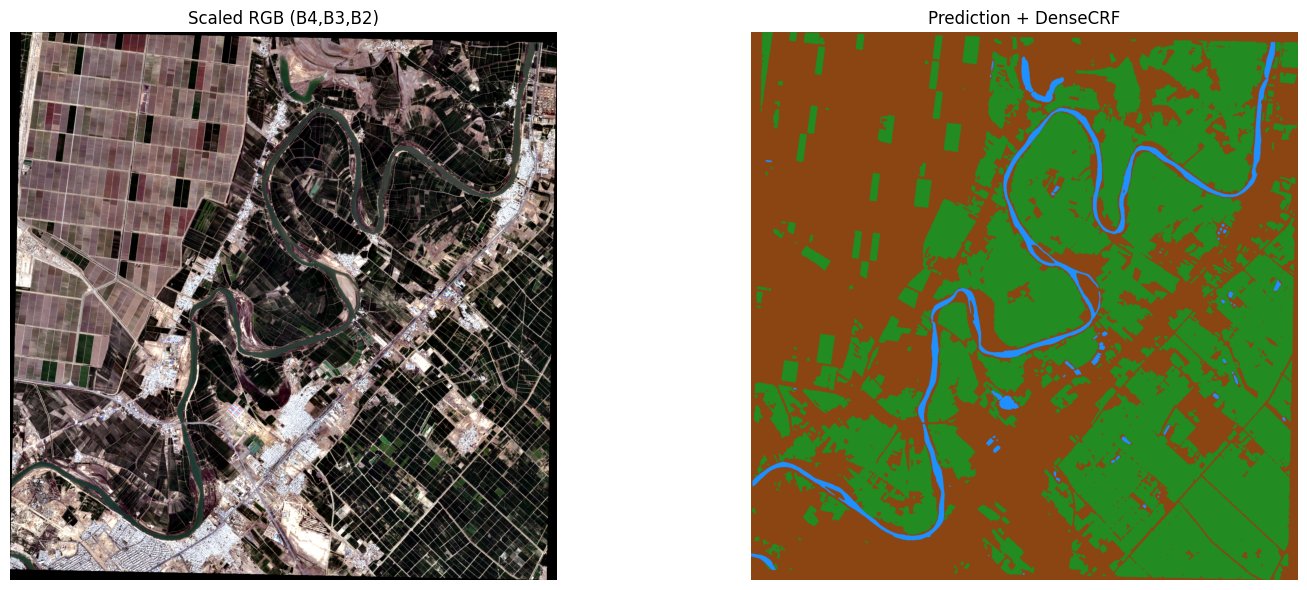

In [14]:
import time, numpy as np, torch, rasterio, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from skimage.morphology import opening, closing, square, remove_small_objects

# params
PATCH_SIZE = 256   # tile size
STRIDE     = 128   # overlap step
BATCH_SIZE = 8     # batch size
USE_CRF    = True  # DenseCRF on/off
ALPHA_PRIOR= 0.6   # fusion weight for index priors

Ck = img_with_indices.shape[-1]

# helpers
def scale_orig_bands(x_hw_c, band_stats, orig_bands=ORIG_BANDS):
    """Scale original bands to [0,1]."""
    x = np.nan_to_num(x_hw_c, nan=0.0).astype(np.float32, copy=True)
    for c, (lo, hi) in enumerate(band_stats[:orig_bands]):
        x[..., c] = np.clip((x[..., c] - lo) / (hi - lo + 1e-6), 0.0, 1.0)
    return x

def preprocess_tile(tile, band_stats, orig_bands=ORIG_BANDS):
    return scale_orig_bands(tile, band_stats, orig_bands)

def tta_forward(xb_t: torch.Tensor) -> np.ndarray:
    """Simple TTA: flips + rotations."""
    outs = []
    outs.append(torch.softmax(model(xb_t), dim=1))  # id
    outs.append(torch.flip(torch.softmax(model(torch.flip(xb_t, [-1])), dim=1), [-1]))
    outs.append(torch.flip(torch.softmax(model(torch.flip(xb_t, [-2])), dim=1), [-2]))
    outs.append(torch.flip(torch.softmax(model(torch.flip(xb_t, [-1, -2])), dim=1), [-1, -2]))
    r = torch.rot90(xb_t, 1, dims=[-2, -1])
    outs.append(torch.rot90(torch.softmax(model(r), dim=1), -1, dims=[-2, -1]))
    r = torch.rot90(xb_t, 3, dims=[-2, -1])
    outs.append(torch.rot90(torch.softmax(model(r), dim=1), 1, dims=[-2, -1]))
    return torch.stack(outs, 0).mean(0).cpu().numpy()

# cosine blend to reduce seams
yy, xx = np.meshgrid(np.linspace(0, np.pi, PATCH_SIZE),
                     np.linspace(0, np.pi, PATCH_SIZE), indexing='ij')
BLEND_WIN = ((0.5 - 0.5*np.cos(yy)) * (0.5 - 0.5*np.cos(xx))).astype(np.float32)

# sliding-window inference
t0 = time.time()
prob  = np.zeros((NUM_CLASSES, H, W), np.float32)
wacc  = np.zeros((H, W), np.float32)
tiles_batch, coords_batch = [], []

model.eval()
autocast_on = (DEVICE.type == 'cuda')
with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=autocast_on):
    for y in tqdm(range(0, H, STRIDE), desc="Full-scene inference"):
        for x in range(0, W, STRIDE):
            tile = img_with_indices[y:y+PATCH_SIZE, x:x+PATCH_SIZE, :]
            ph, pw = tile.shape[:2]
            if ph < PATCH_SIZE or pw < PATCH_SIZE:
                pad = np.zeros((PATCH_SIZE, PATCH_SIZE, Ck), np.float32)
                pad[:ph, :pw] = tile
                tile = pad
            tile = preprocess_tile(tile, BAND_STATS, ORIG_BANDS)
            xb = torch.from_numpy(np.transpose(tile, (2, 0, 1)))
            tiles_batch.append(xb)
            coords_batch.append((y, x, ph, pw))

            if len(tiles_batch) == BATCH_SIZE:
                xb_t = torch.stack(tiles_batch).to(DEVICE, non_blocking=True)
                p_batch = tta_forward(xb_t)
                for p, (yy0, xx0, hh, ww) in zip(p_batch, coords_batch):
                    w = BLEND_WIN[:hh, :ww]
                    prob[:, yy0:yy0+hh, xx0:xx0+ww] += p[:, :hh, :ww] * w
                    wacc[yy0:yy0+hh, xx0:xx0+ww]    += w
                tiles_batch.clear(); coords_batch.clear()

    if tiles_batch:
        xb_t = torch.stack(tiles_batch).to(DEVICE, non_blocking=True)
        p_batch = tta_forward(xb_t)
        for p, (yy0, xx0, hh, ww) in zip(p_batch, coords_batch):
            w = BLEND_WIN[:hh, :ww]
            prob[:, yy0:yy0+hh, xx0:xx0+ww] += p[:, :hh, :ww] * w
            wacc[yy0:yy0+hh, xx0:xx0+ww]    += w

prob /= np.maximum(wacc[None, ...], 1e-6)
prob  = np.nan_to_num(prob, nan=1.0/NUM_CLASSES)

# priors (NDVI/EVI, NDWI/MNDWI)
ndwi = np.nan_to_num(img_with_indices[..., NAME2IDX["NDWI"]], nan=0.0).astype(np.float32)
w_pr = np.clip((ndwi + 1.0)/2.0, 0.0, 1.0)
if "MNDWI" in NAME2IDX:
    mndwi = np.nan_to_num(img_with_indices[..., NAME2IDX["MNDWI"]], nan=0.0).astype(np.float32)
    w_pr = 0.6*w_pr + 0.4*np.clip((mndwi + 1.0)/2.0, 0.0, 1.0)

ndvi = np.nan_to_num(img_with_indices[..., NAME2IDX["NDVI"]], nan=0.0).astype(np.float32)
v_pr = np.clip((ndvi + 1.0)/2.0, 0.0, 1.0)
if "EVI" in NAME2IDX:
    evi = np.nan_to_num(img_with_indices[..., NAME2IDX["EVI"]], nan=0.0).astype(np.float32)
    v_pr = 0.7*v_pr + 0.3*np.clip((evi + 1.0)/2.0, 0.0, 1.0)

s_pr = np.clip(1.0 - np.maximum(v_pr, w_pr), 0.0, 1.0)
priors = np.stack([s_pr, v_pr, w_pr], axis=0)
priors = np.clip(priors, 1e-4, 1.0)

# fusion
logp   = np.log(np.clip(prob, 1e-6, 1.0))
logpri = np.log(priors)
fused  = np.exp(logp + ALPHA_PRIOR * logpri)
fused  = fused / np.maximum(fused.sum(axis=0, keepdims=True), 1e-6)

# optional DenseCRF
if USE_CRF:
    try:
        import pydensecrf.densecrf as dcrf
        from pydensecrf.utils import unary_from_softmax, create_pairwise_bilateral
        rgb01 = scale_orig_bands(np.nan_to_num(img_with_indices, nan=0.0), BAND_STATS, ORIG_BANDS)[..., [NAME2IDX["B4"], NAME2IDX["B3"], NAME2IDX["B2"]]]
        rgb_u8 = np.clip(rgb01*255.0, 0, 255).astype(np.uint8)
        d = dcrf.DenseCRF2D(W, H, NUM_CLASSES)
        U = unary_from_softmax(fused.astype(np.float32))
        d.setUnaryEnergy(U)
        d.addPairwiseGaussian(sxy=3, compat=4)
        feats = create_pairwise_bilateral(sdims=(60,60), schan=(6,6,6), img=rgb_u8, chdim=2)
        d.addPairwiseEnergy(feats, compat=6)
        Q = np.array(d.inference(6)).reshape((NUM_CLASSES, H, W))
        pred_full = Q.argmax(axis=0).astype(np.uint8)
    except Exception as e:
        print("[WARN] DenseCRF failed, fallback used:", e)
        pred_full = fused.argmax(0).astype(np.uint8)
else:
    pred_full = fused.argmax(0).astype(np.uint8)

# cleanup
for cls, min_size, k in [(VEG, 36, 3), (WATER, 9, 3)]:
    m = (pred_full == cls)
    m = opening(m, square(k))
    m = closing(m, square(k))
    m = remove_small_objects(m, min_size)
    pred_full[(pred_full == cls) & (~m)] = SOIL
    pred_full[m] = cls

# export
t1 = time.time()
print(f"[TIME] Inference{' + CRF' if USE_CRF else ''}: {t1 - t0:.1f}s | Scene: {H}x{W}")

EXP_DIR.mkdir(parents=True, exist_ok=True)
OUT_TIF = EXP_DIR / "prediction_fullscene.tif"
OUT_PNG = EXP_DIR / "prediction_fullscene_rgb.png"

profile = meta.copy(); profile.update(count=1, dtype='uint8', compress='lzw')
with rasterio.open(OUT_TIF, "w", **profile) as dst:
    dst.write(pred_full, 1)

def mask_to_rgb_full(mask):
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for k, c in PALETTE_RGB.items():
        rgb[mask == k] = c
    return rgb

rgb_pred = mask_to_rgb_full(pred_full)
Image.fromarray(rgb_pred).save(OUT_PNG)

print(f"[INFO] GeoTIFF → {OUT_TIF}")
print(f"[INFO] Preview PNG → {OUT_PNG}")

# quick preview
rgb_disp = (np.clip(
    scale_orig_bands(np.nan_to_num(img_with_indices, nan=0.0), BAND_STATS, ORIG_BANDS)[..., [NAME2IDX["B4"], NAME2IDX["B3"], NAME2IDX["B2"]]],
    0, 1
) * 255).astype(np.uint8)

plt.figure(figsize=(16,6))
plt.subplot(1,2,1); plt.imshow(rgb_disp); plt.title("Scaled RGB (B4,B3,B2)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(rgb_pred); plt.title(f"Prediction{' + DenseCRF' if USE_CRF else ''}"); plt.axis("off")
plt.tight_layout(); plt.show()
